# 2. ECG Signal Preprocessing and Denoising Techniques

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import (
    bessel,
    butter,
    cheby1,
    cheby2,
    ellip,
    iirnotch,
    sosfiltfilt,
    sosfreqz,
    tf2sos,
)

from _nb_helper import save_plot, setup_notebook

from ecg_waveform.config import load_yaml, save_yaml
from ecg_waveform.signal.preprocessing import (
    Preprocessor,
    bessel_filter,
    butterworth_filter,
    chebyshev1_filter,
    chebyshev2_filter,
    elliptic_filter,
    median_baseline_filter,
    median_smooth,
    notch_filter,
    savgol_smooth,
    wavelet_denoise,
)
from ecg_waveform.signal.quality import SignalQualityAssessor
from ecg_waveform.signal.simulation import simulate_ecg
from ecg_waveform.utils import compute_snr
from ecg_waveform.visualization import (
    plot_baseline_wander,
    plot_signal,
    plot_psd,
    plot_fft,
)

setup_notebook()

In [5]:
DURATION_SEC: float = 300.0
SAMPLE_RATE: int = 500
HEART_RATE_BPM: float = 60.0
HRV_STD_SEC: float = 0.03
RANDOM_SEED: int = 42

WINDOW1_MS: int = 200
WINDOW2_MS: int = 600

FREQ_50_HZ: float = 50.0
FREQ_60_HZ: float = 60.0
QUALITY_FACTOR: float = 30.0

LOW_CUTOFF_HZ: float = 0.5
HIGH_CUTOFF_HZ: float = 40.0
ORDER: int = 4
RIPPLE_DB: float = 1.0
ATTENUATION_DB: float = 40.0

KERNEL_MS: float = 20.0
WINDOW_MS: float = 50.0
POLYORDER: int = 3
WAVELET: str = "db4"
LEVEL: int = 4

In [6]:
assessor_config = load_yaml("quality/quality_assessment_config.yaml")
assessor = SignalQualityAssessor.from_config(assessor_config)

---

In [7]:
reference_signal = simulate_ecg(
    duration_sec=DURATION_SEC,
    sample_rate=SAMPLE_RATE,
    heart_rate_bpm=HEART_RATE_BPM,
    hrv_std_sec=HRV_STD_SEC,
    noise=None,
    seed=RANDOM_SEED,
)

raw_signal = simulate_ecg(
    duration_sec=DURATION_SEC,
    sample_rate=SAMPLE_RATE,
    heart_rate_bpm=HEART_RATE_BPM,
    hrv_std_sec=HRV_STD_SEC,
    seed=RANDOM_SEED,
)

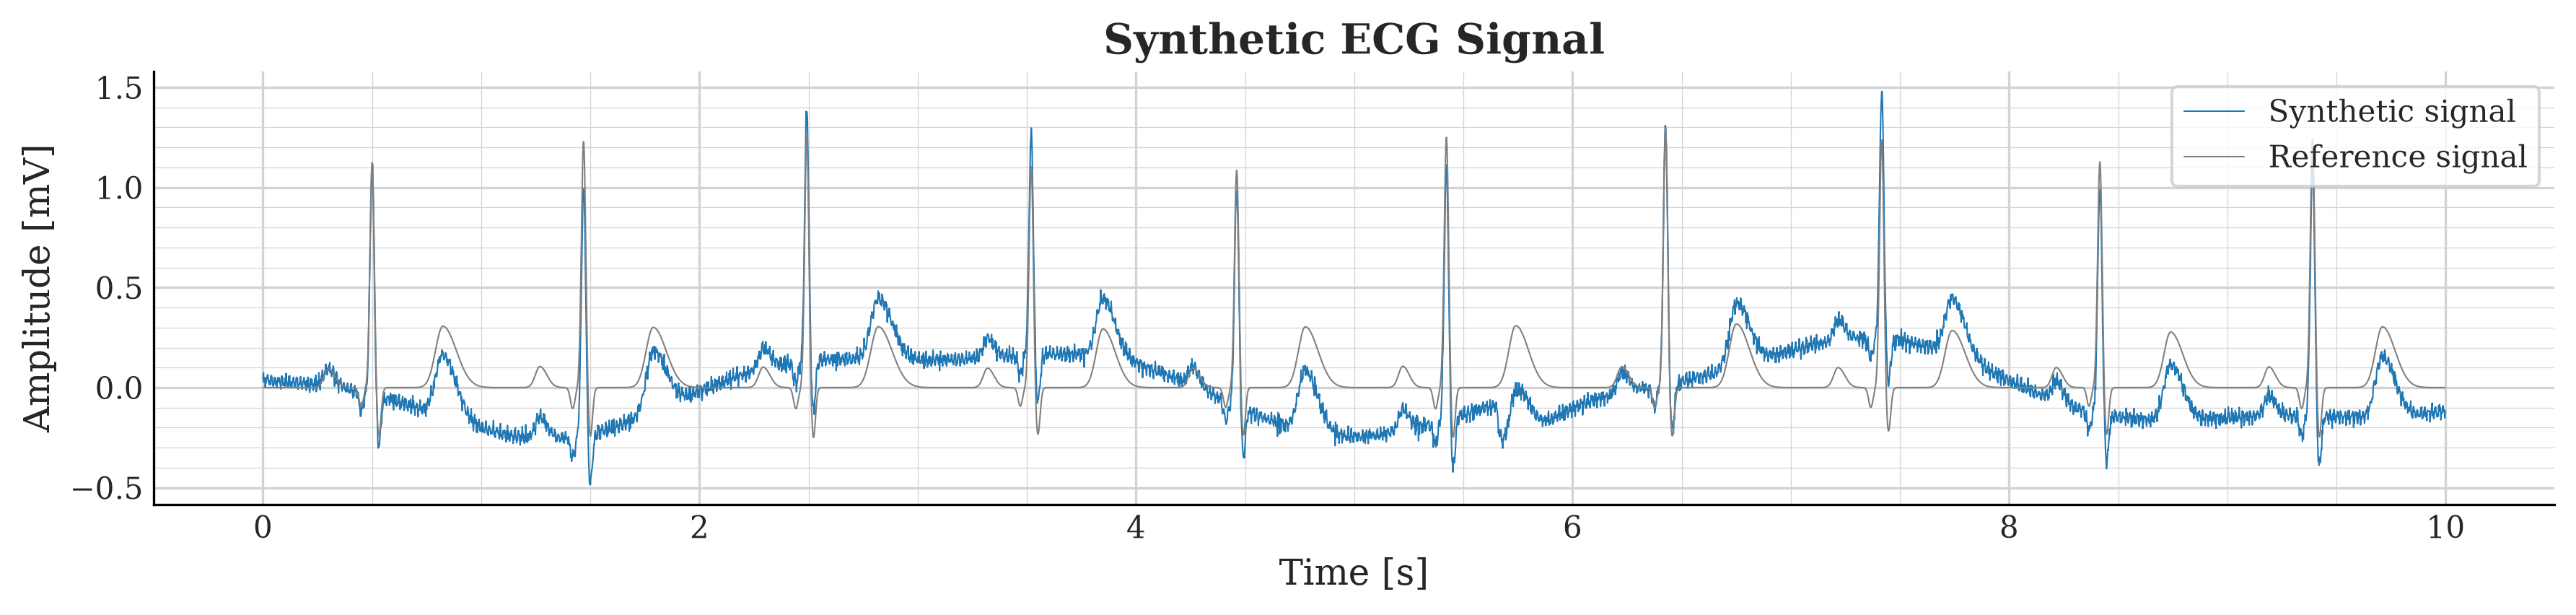

In [8]:
fig, ax = plt.subplots()

plot_signal(
    raw_signal,
    start_sec=0,
    interval_sec=10,
    show_annotation=False,
    ax=ax,
    label="Synthetic signal",
)

plot_signal(
    reference_signal,
    start_sec=0,
    interval_sec=10,
    show_annotation=False,
    ax=ax,
    color="gray",
    label="Reference signal",
)

ax.set_title("Synthetic ECG Signal")

fig.tight_layout(rect=(0, 0, 1, 0.98))

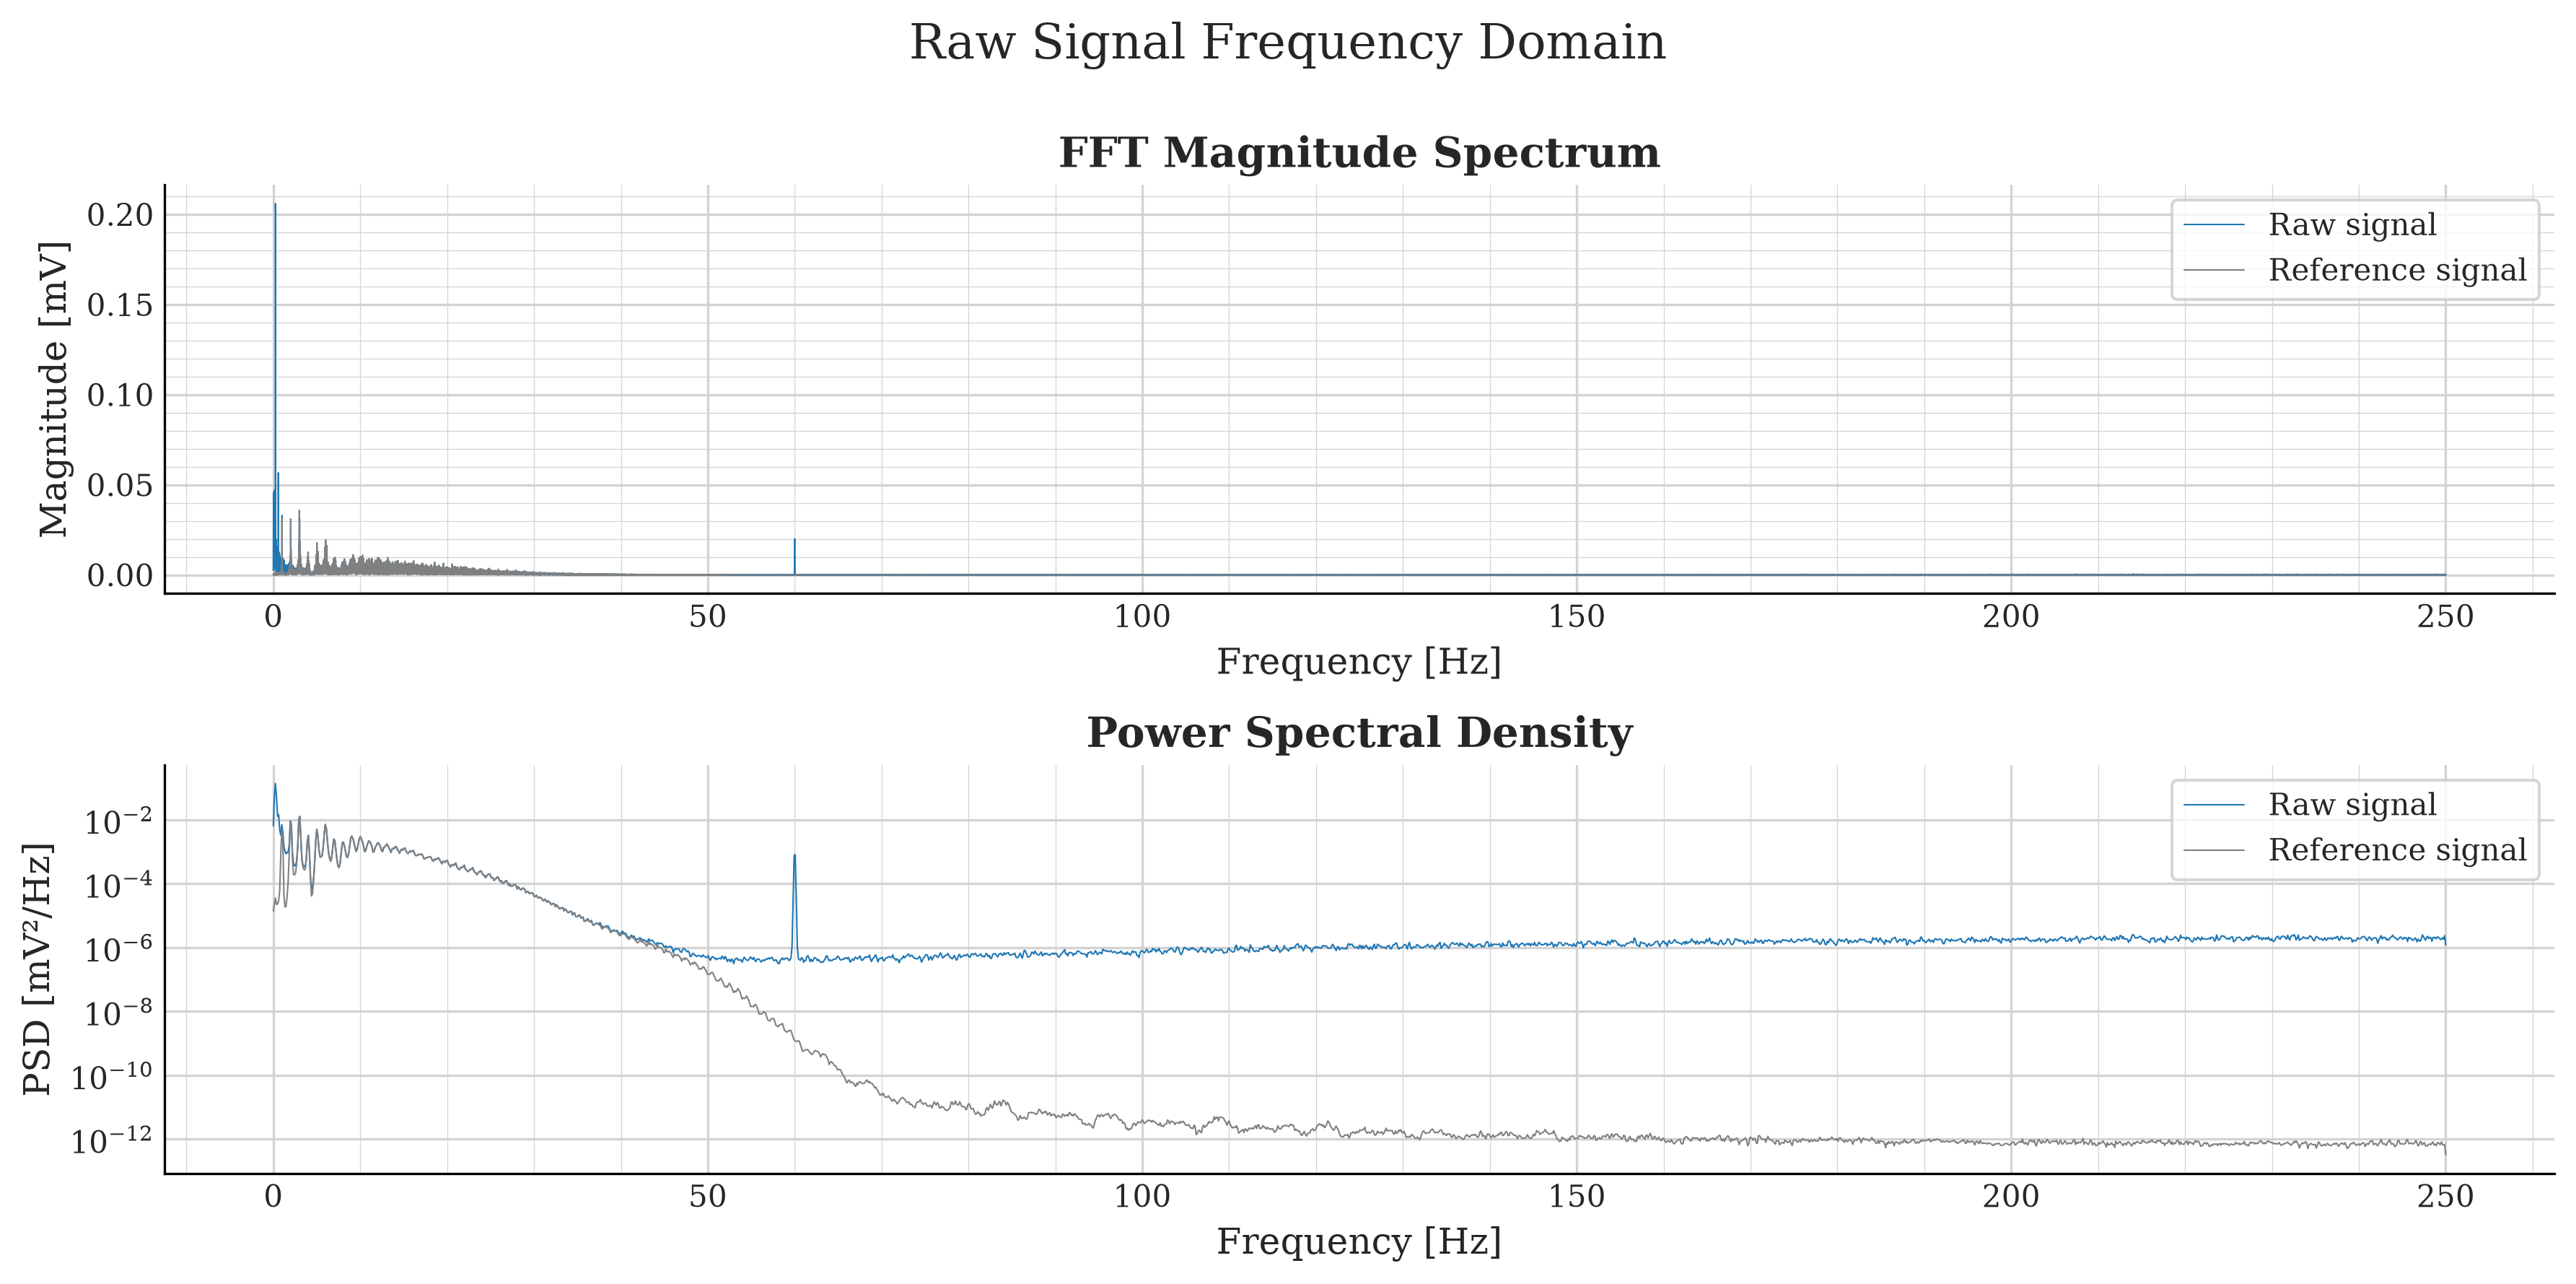

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

plot_fft(raw_signal, ax=ax1, label="Raw signal")
plot_psd(raw_signal, ax=ax2, label="Raw signal")

plot_fft(reference_signal, ax=ax1, color="gray", label="Reference signal")
plot_psd(reference_signal, ax=ax2, color="gray", label="Reference signal")

ax1.legend()
ax2.legend()

fig.suptitle("Raw Signal Frequency Domain", fontsize=16)
fig.tight_layout(rect=(0, 0, 1, 0.98))

In [10]:
snr = compute_snr(reference_signal, raw_signal)

print(f"SNR = {snr:.2f} dB")

result = assessor.assess(raw_signal)

print(result)

SNR = -0.79 dB
QualityReport[BAD, score=0.80]
  kurtosis_sqi           =   4.4548  [ACCEPTABLE]
  qrs_power_sqi          =   0.4775  [GOOD]
  powerline_50hz         =   0.0000  [GOOD]
  powerline_60hz         =   0.0031  [GOOD]
  baseline_wander_ratio  =   0.4983  [BAD]
  flatline_ratio         =   0.0000  [GOOD]


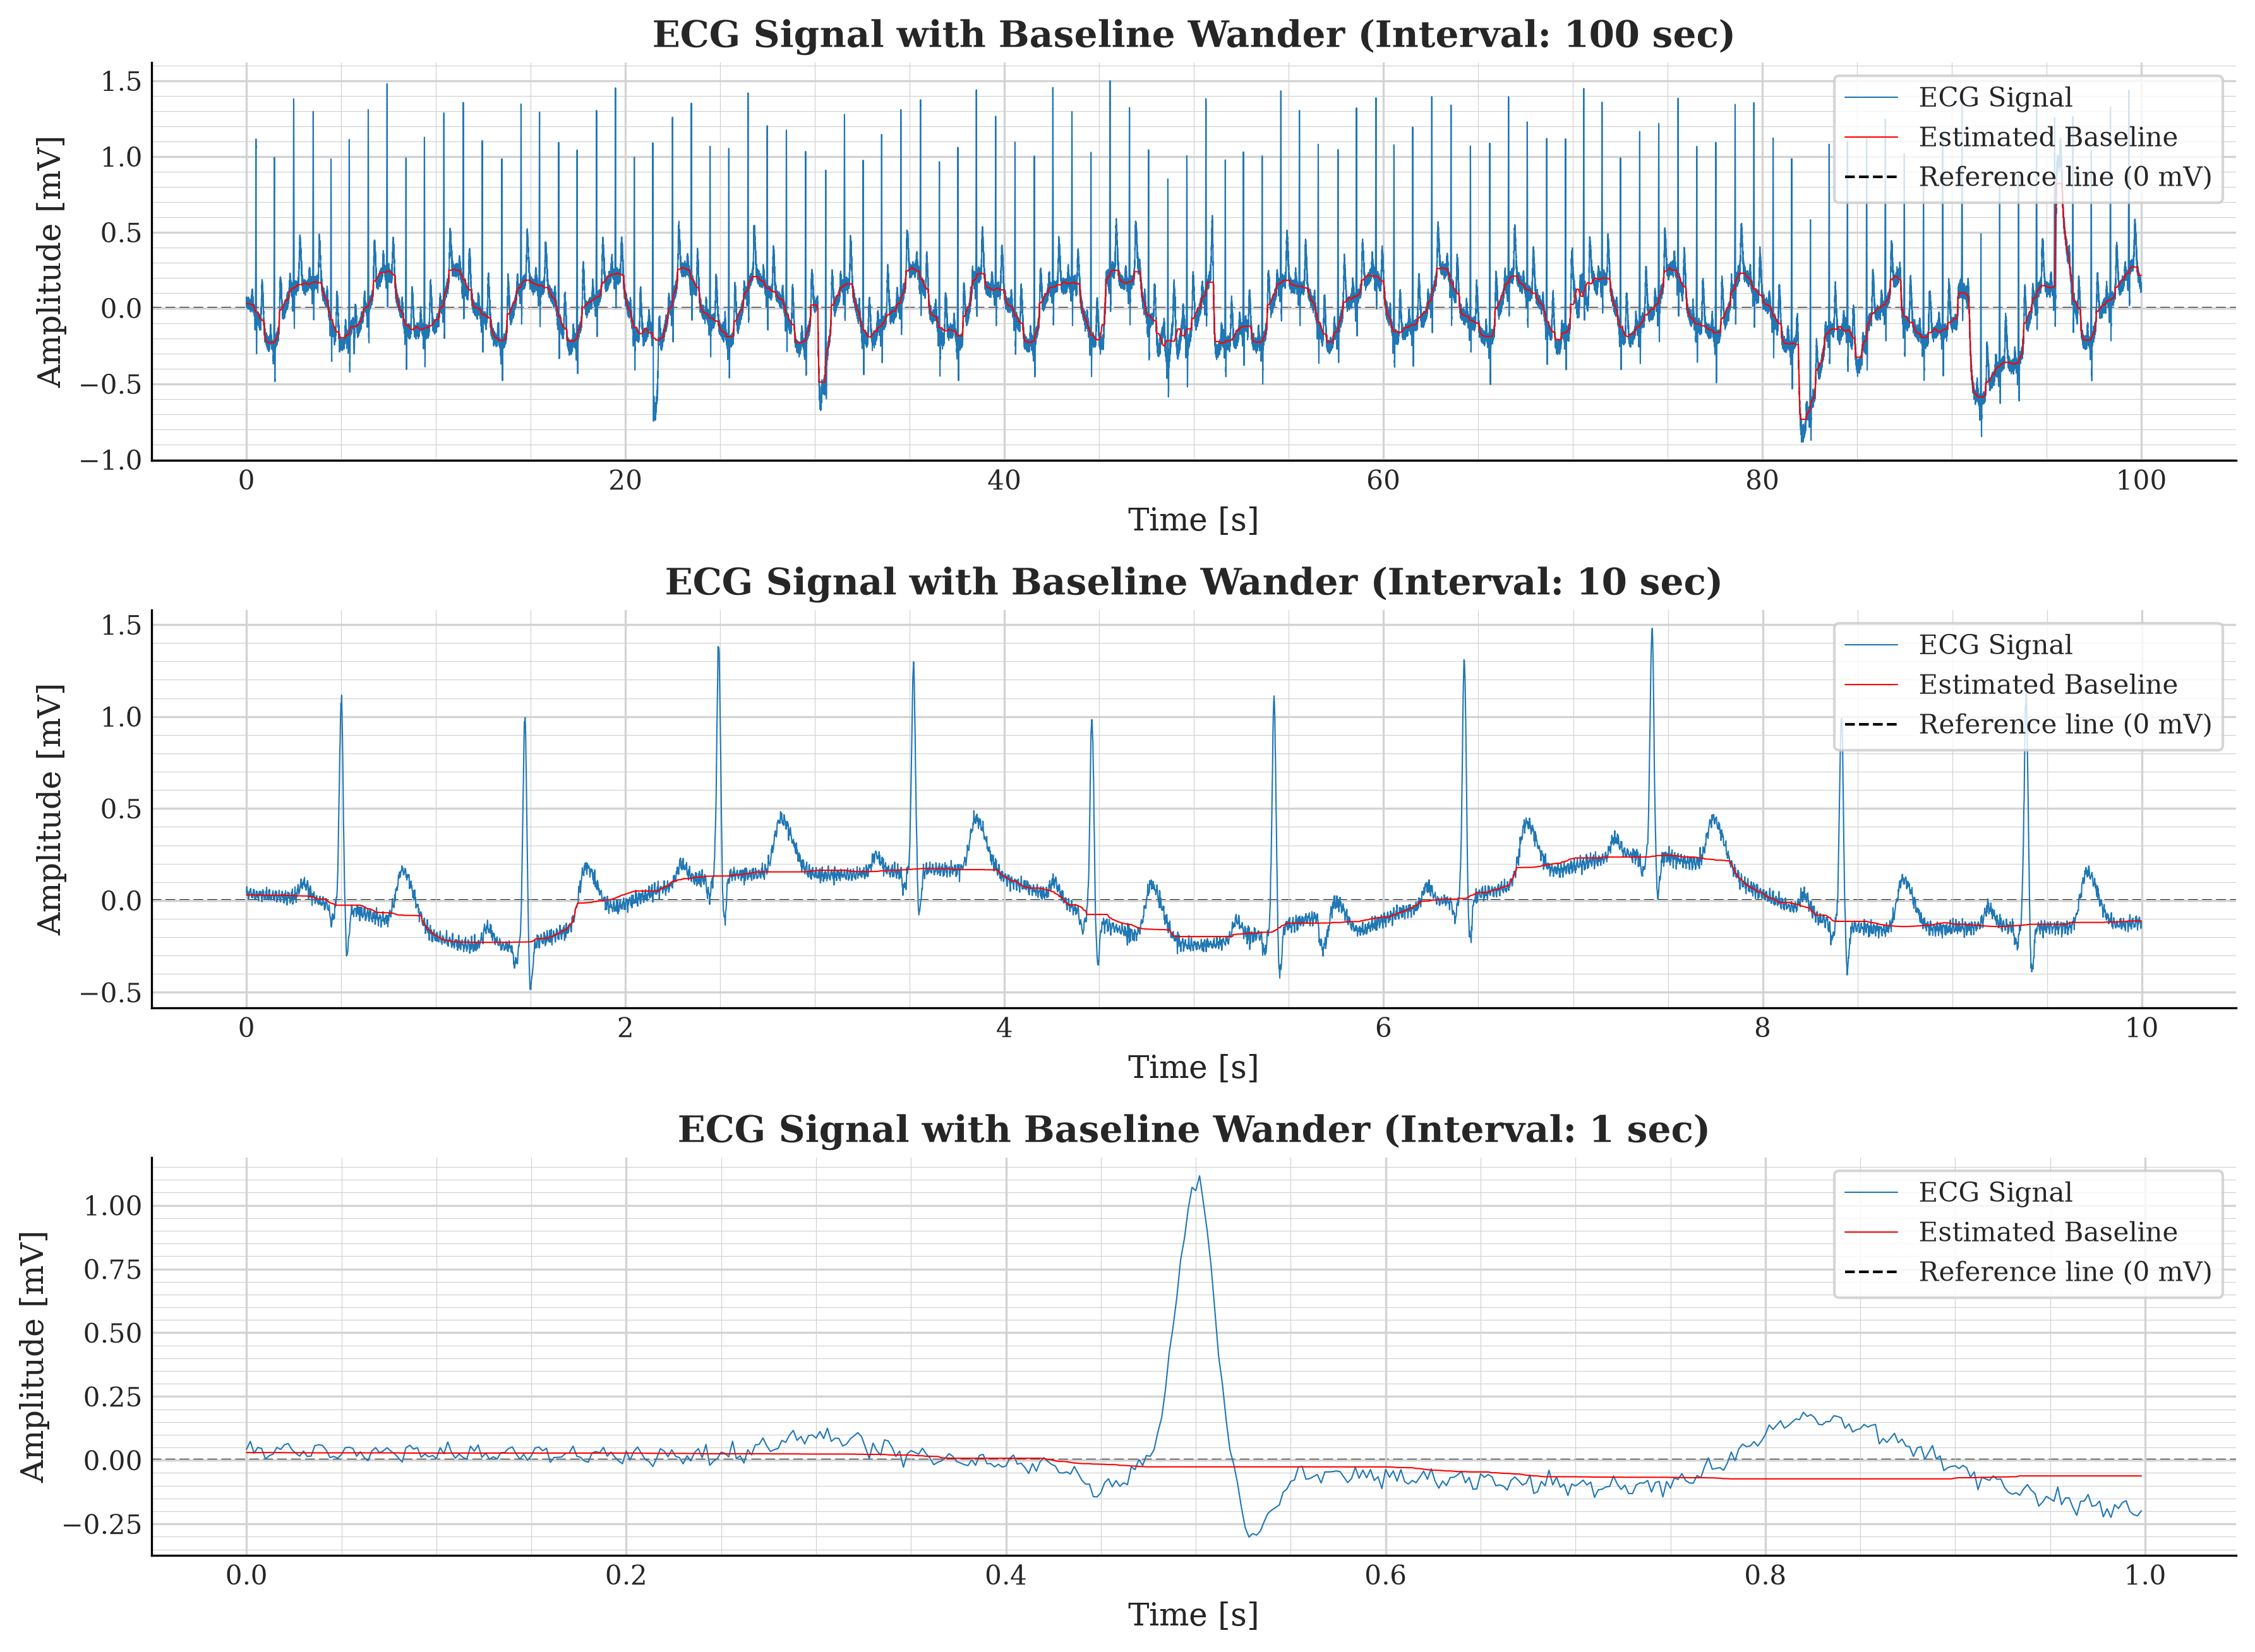

In [11]:
INTERVALS = (100, 10, 1)

fig, axes = plt.subplots(len(INTERVALS), 1, figsize=(12, 3 * len(INTERVALS)))

for ax, interval in zip(axes, INTERVALS):
    plot_signal(raw_signal, show_annotation=False, interval_sec=interval, ax=ax)
    plot_baseline_wander(raw_signal, interval_sec=interval, ax=ax)

    ax.axhline(
        y=0,
        color="black",
        linestyle="--",
        linewidth=1,
        zorder=0,
        label="Reference line (0 mV)",
    )

    ax.set_title(f"ECG Signal with Baseline Wander (Interval: {interval} sec)")

    ax.legend()

fig.tight_layout(rect=(0, 0, 1, 0.98))

save_plot(fig, "Baseline wander at multiple time scales")

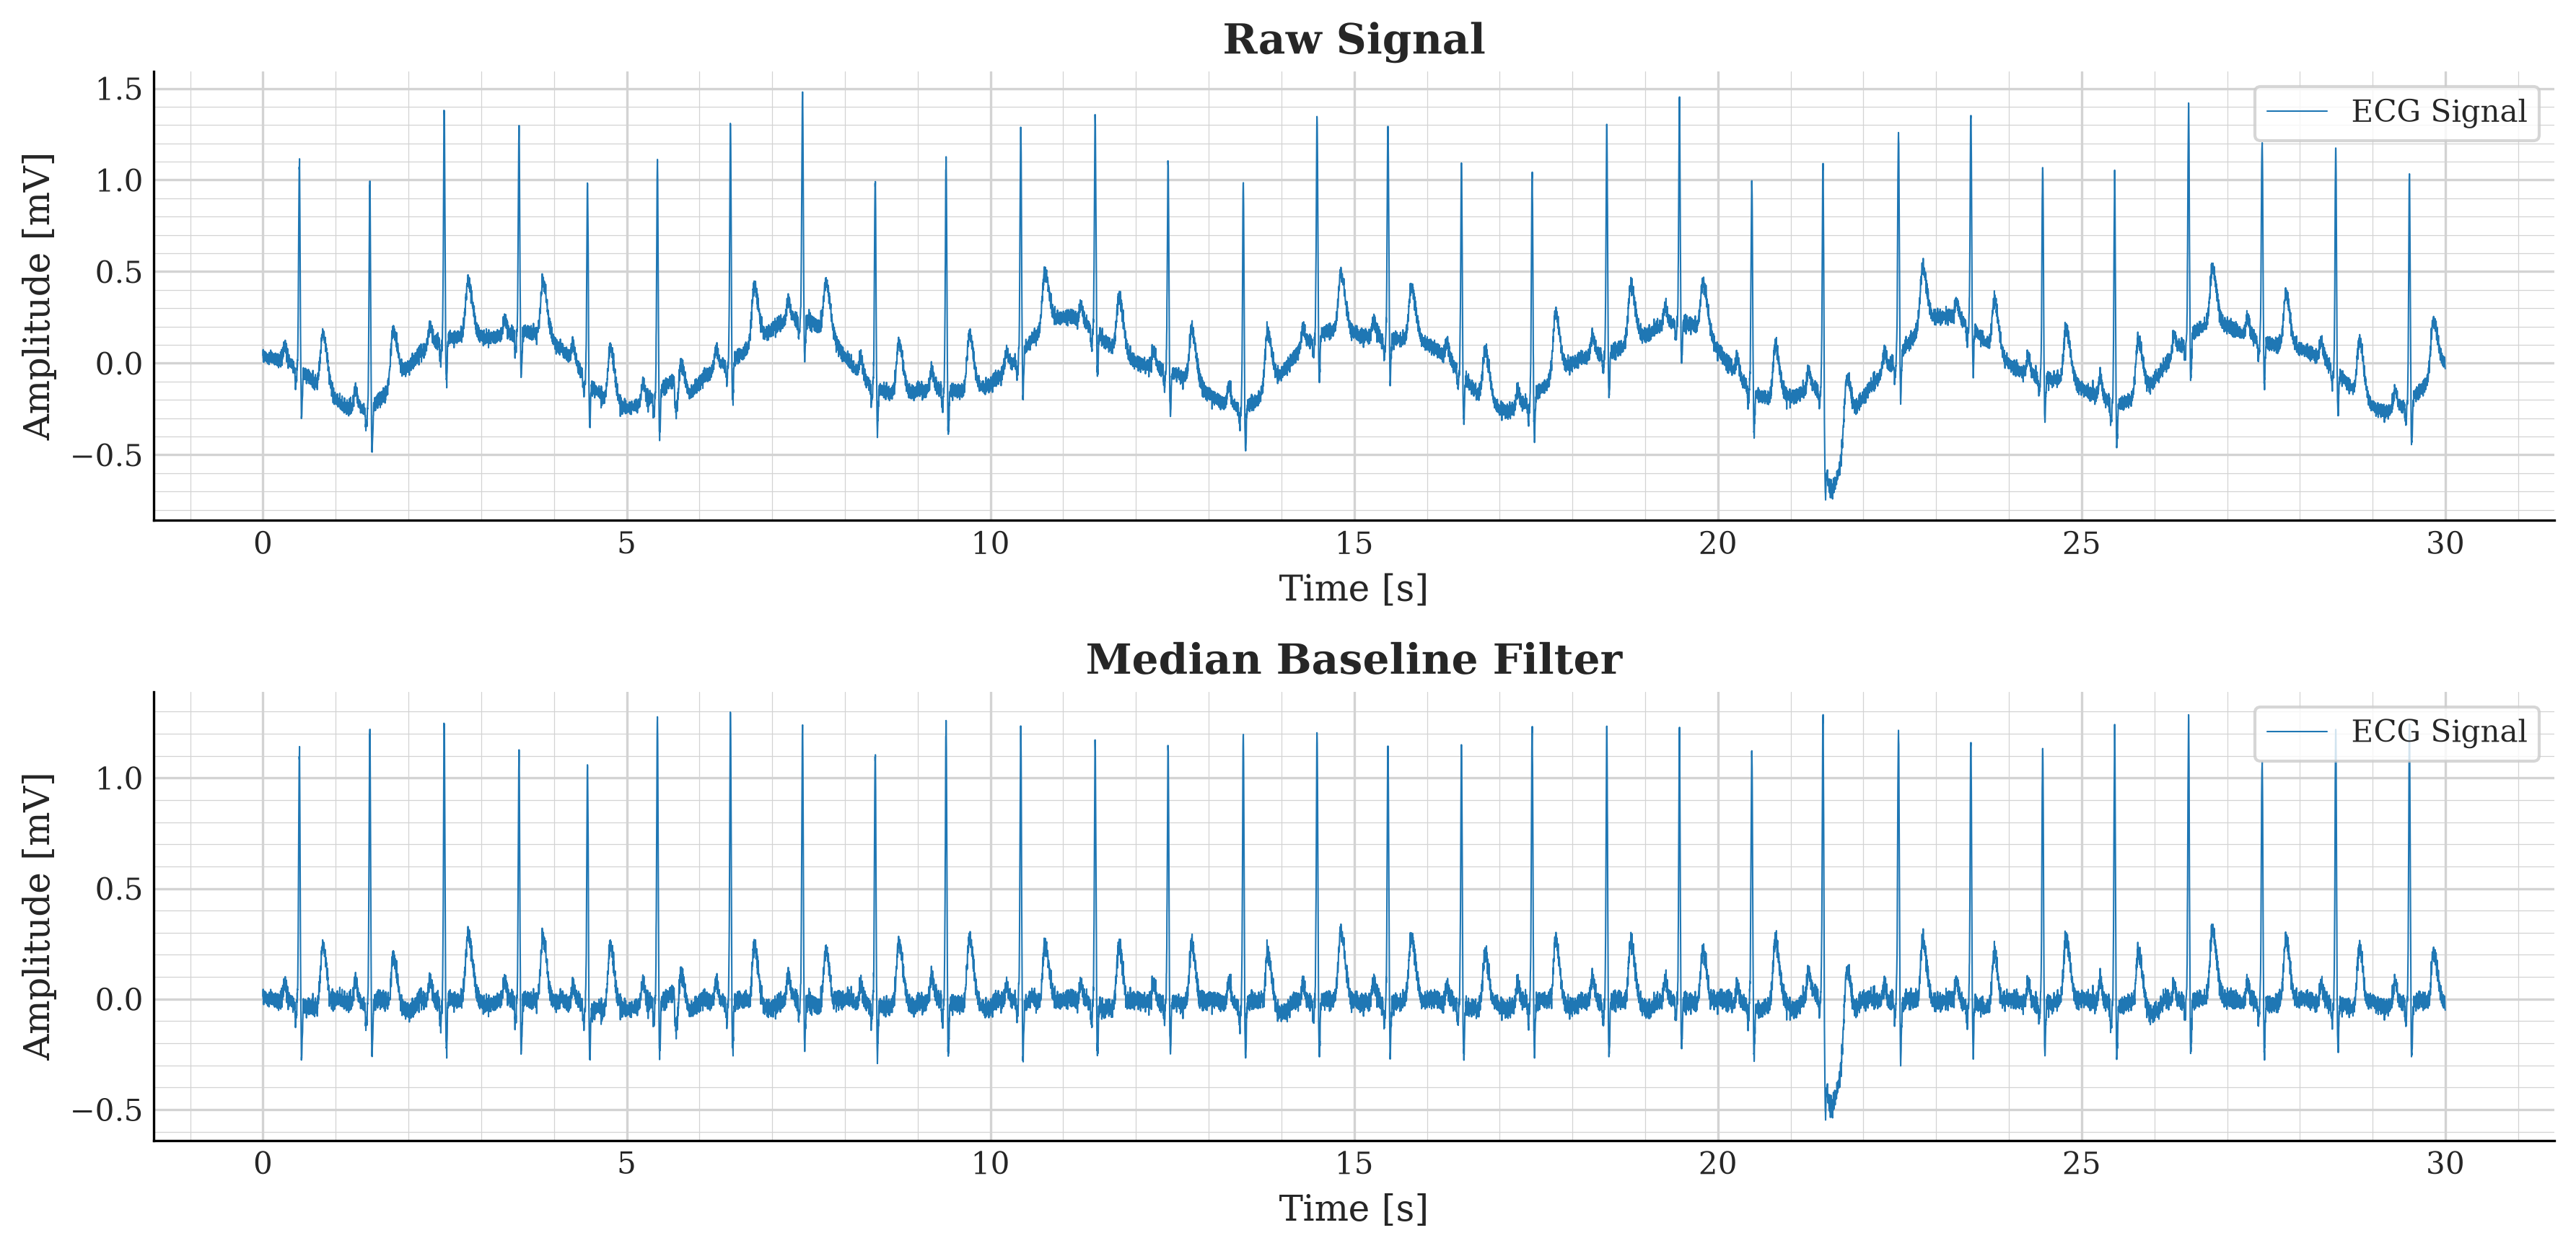

In [12]:
SIGNALS = {
    "Raw Signal": raw_signal,
    "Median Baseline Filter": median_baseline_filter(
        raw_signal, window1_ms=WINDOW1_MS, window2_ms=WINDOW2_MS
    ),
}

fig, axes = plt.subplots(len(SIGNALS), 1, figsize=(12, 3 * len(SIGNALS)))

axes = np.atleast_1d(axes).ravel()

for ax, (name, signal) in zip(axes, SIGNALS.items()):
    plot_signal(
        signal,
        start_sec=0,
        interval_sec=30,
        show_annotation=False,
        title=name,
        ax=ax,
    )

fig.tight_layout(rect=(0, 0, 1, 0.98))

save_plot(fig, "Baseline wander removal filters comparison")

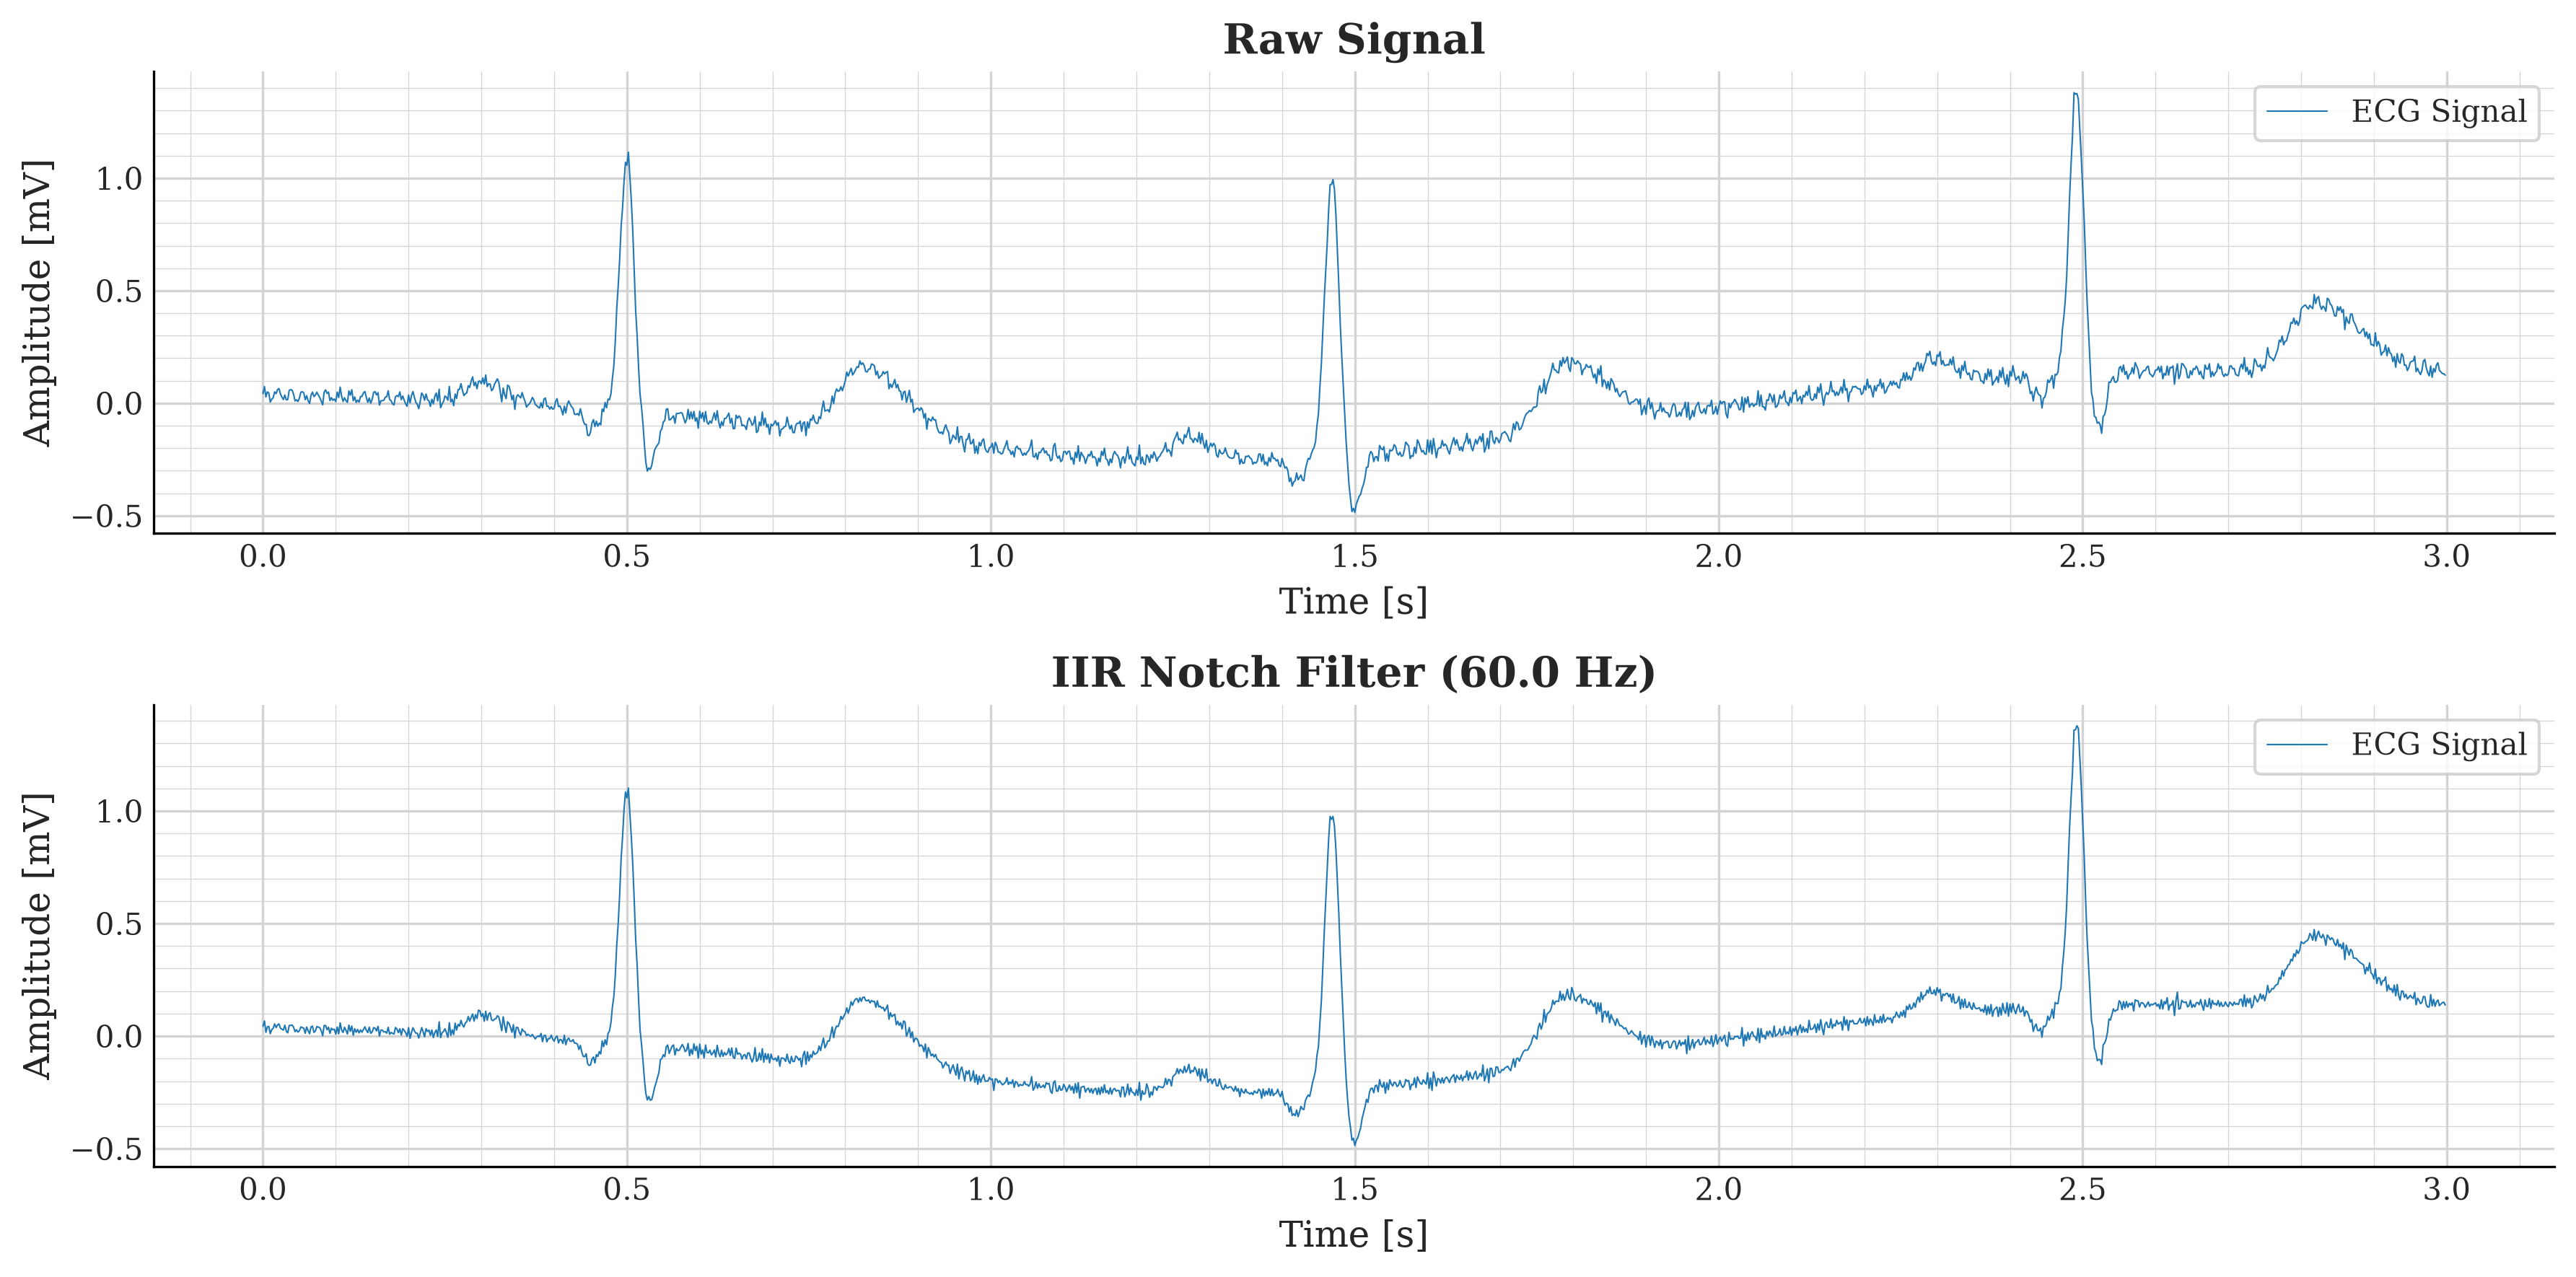

In [13]:
SIGNALS = {
    "Raw Signal": raw_signal,
    f"IIR Notch Filter ({FREQ_60_HZ} Hz)": notch_filter(
        raw_signal, freq=FREQ_60_HZ, quality_factor=QUALITY_FACTOR
    ),
}

fig, axes = plt.subplots(len(SIGNALS), 1, figsize=(12, 3 * len(SIGNALS)))

axes = np.atleast_1d(axes).ravel()

for ax, (name, signal) in zip(axes, SIGNALS.items()):
    plot_signal(
        signal,
        start_sec=0,
        interval_sec=3,
        show_annotation=False,
        title=name,
        ax=ax,
    )

fig.tight_layout()

save_plot(fig, "Powerline interference removal filters comparison")

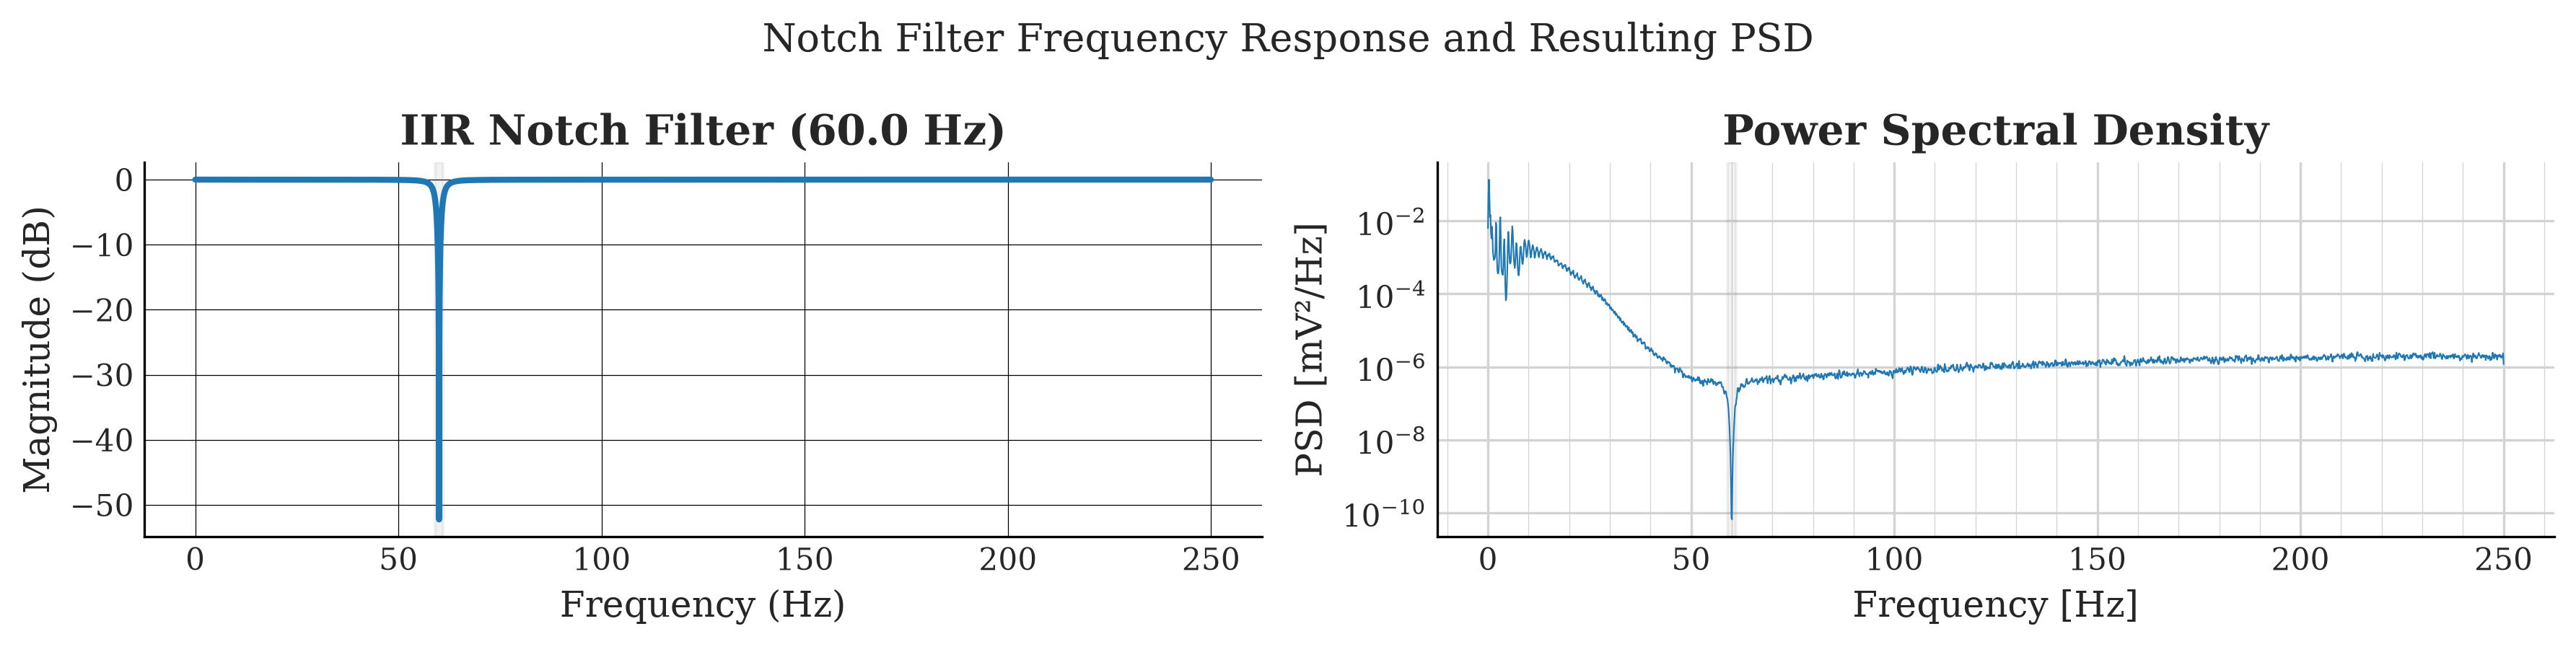

In [14]:
b, a = iirnotch(FREQ_60_HZ, QUALITY_FACTOR, raw_signal.sample_rate)
sos = tf2sos(b, a)
w, h = sosfreqz(sos, worN=4096, fs=raw_signal.sample_rate)

filtered = raw_signal.with_sample(sosfiltfilt(sos, raw_signal.sample))

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

axes[0].plot(w, 20 * np.log10(np.maximum(np.abs(h), 1e-10)), lw=2)
axes[0].axvspan(FREQ_60_HZ - 1, FREQ_60_HZ + 1, color="gray", alpha=0.1)
axes[0].set_title(f"IIR Notch Filter ({FREQ_60_HZ} Hz)")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Magnitude (dB)")

plot_psd(filtered, ax=axes[1])
axes[1].axvspan(FREQ_60_HZ - 1, FREQ_60_HZ + 1, color="gray", alpha=0.1)

fig.suptitle("Notch Filter Frequency Response and Resulting PSD", fontsize=13)
fig.tight_layout()

save_plot(fig, "Notch filter response and resulting PSD")

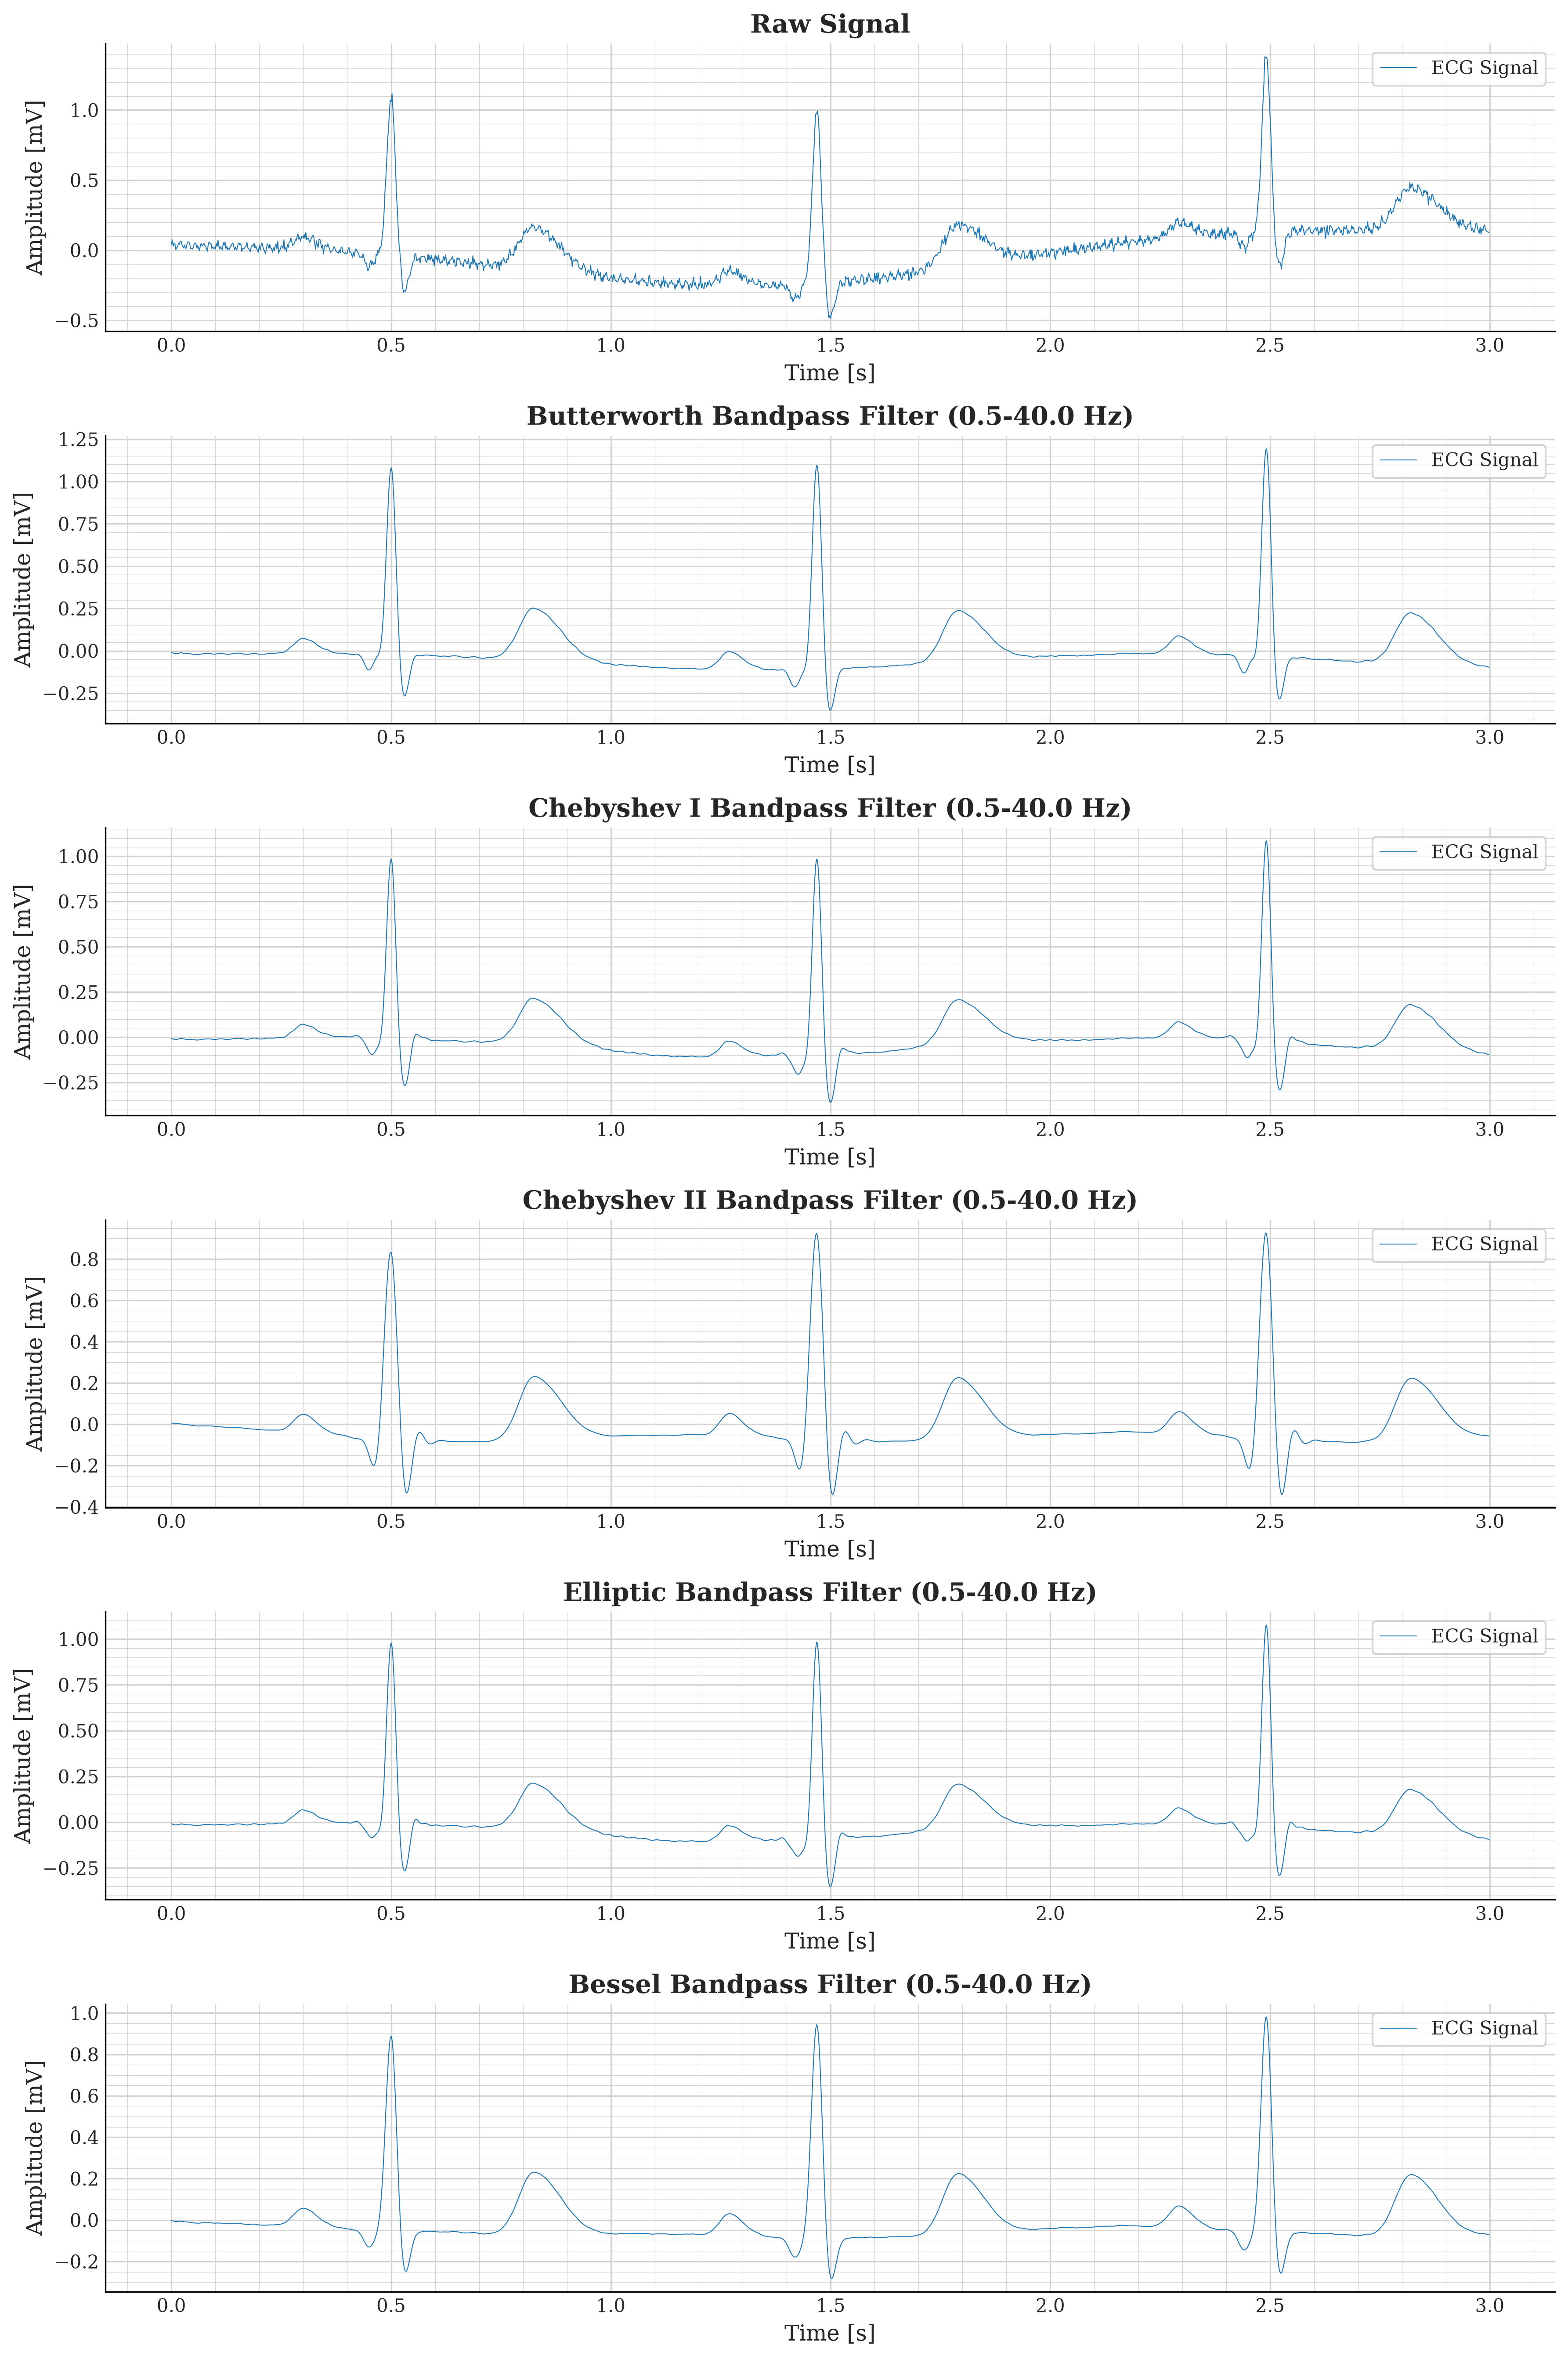

In [15]:
SIGNALS = {
    "Raw Signal": raw_signal,
    f"Butterworth Bandpass Filter ({LOW_CUTOFF_HZ}-{HIGH_CUTOFF_HZ} Hz)": butterworth_filter(
        raw_signal,
        low_cutoff=LOW_CUTOFF_HZ,
        high_cutoff=HIGH_CUTOFF_HZ,
        order=ORDER,
    ),
    f"Chebyshev I Bandpass Filter ({LOW_CUTOFF_HZ}-{HIGH_CUTOFF_HZ} Hz)": chebyshev1_filter(
        raw_signal,
        low_cutoff=LOW_CUTOFF_HZ,
        high_cutoff=HIGH_CUTOFF_HZ,
        order=ORDER,
        ripple_db=RIPPLE_DB,
    ),
    f"Chebyshev II Bandpass Filter ({LOW_CUTOFF_HZ}-{HIGH_CUTOFF_HZ} Hz)": chebyshev2_filter(
        raw_signal,
        low_cutoff=LOW_CUTOFF_HZ,
        high_cutoff=HIGH_CUTOFF_HZ,
        order=ORDER,
        attenuation_db=ATTENUATION_DB,
    ),
    f"Elliptic Bandpass Filter ({LOW_CUTOFF_HZ}-{HIGH_CUTOFF_HZ} Hz)": elliptic_filter(
        raw_signal,
        low_cutoff=LOW_CUTOFF_HZ,
        high_cutoff=HIGH_CUTOFF_HZ,
        order=ORDER,
        ripple_db=RIPPLE_DB,
        attenuation_db=ATTENUATION_DB,
    ),
    f"Bessel Bandpass Filter ({LOW_CUTOFF_HZ}-{HIGH_CUTOFF_HZ} Hz)": bessel_filter(
        raw_signal,
        low_cutoff=LOW_CUTOFF_HZ,
        high_cutoff=HIGH_CUTOFF_HZ,
        order=ORDER,
    ),
}

fig, axes = plt.subplots(len(SIGNALS), 1, figsize=(12, 3 * len(SIGNALS)))

axes = np.atleast_1d(axes).ravel()

for ax, (name, signal) in zip(axes, SIGNALS.items()):
    plot_signal(
        signal,
        start_sec=0,
        interval_sec=3,
        show_annotation=False,
        title=name,
        ax=ax,
    )

fig.tight_layout()

save_plot(fig, "Bandpass-filter family comparison")

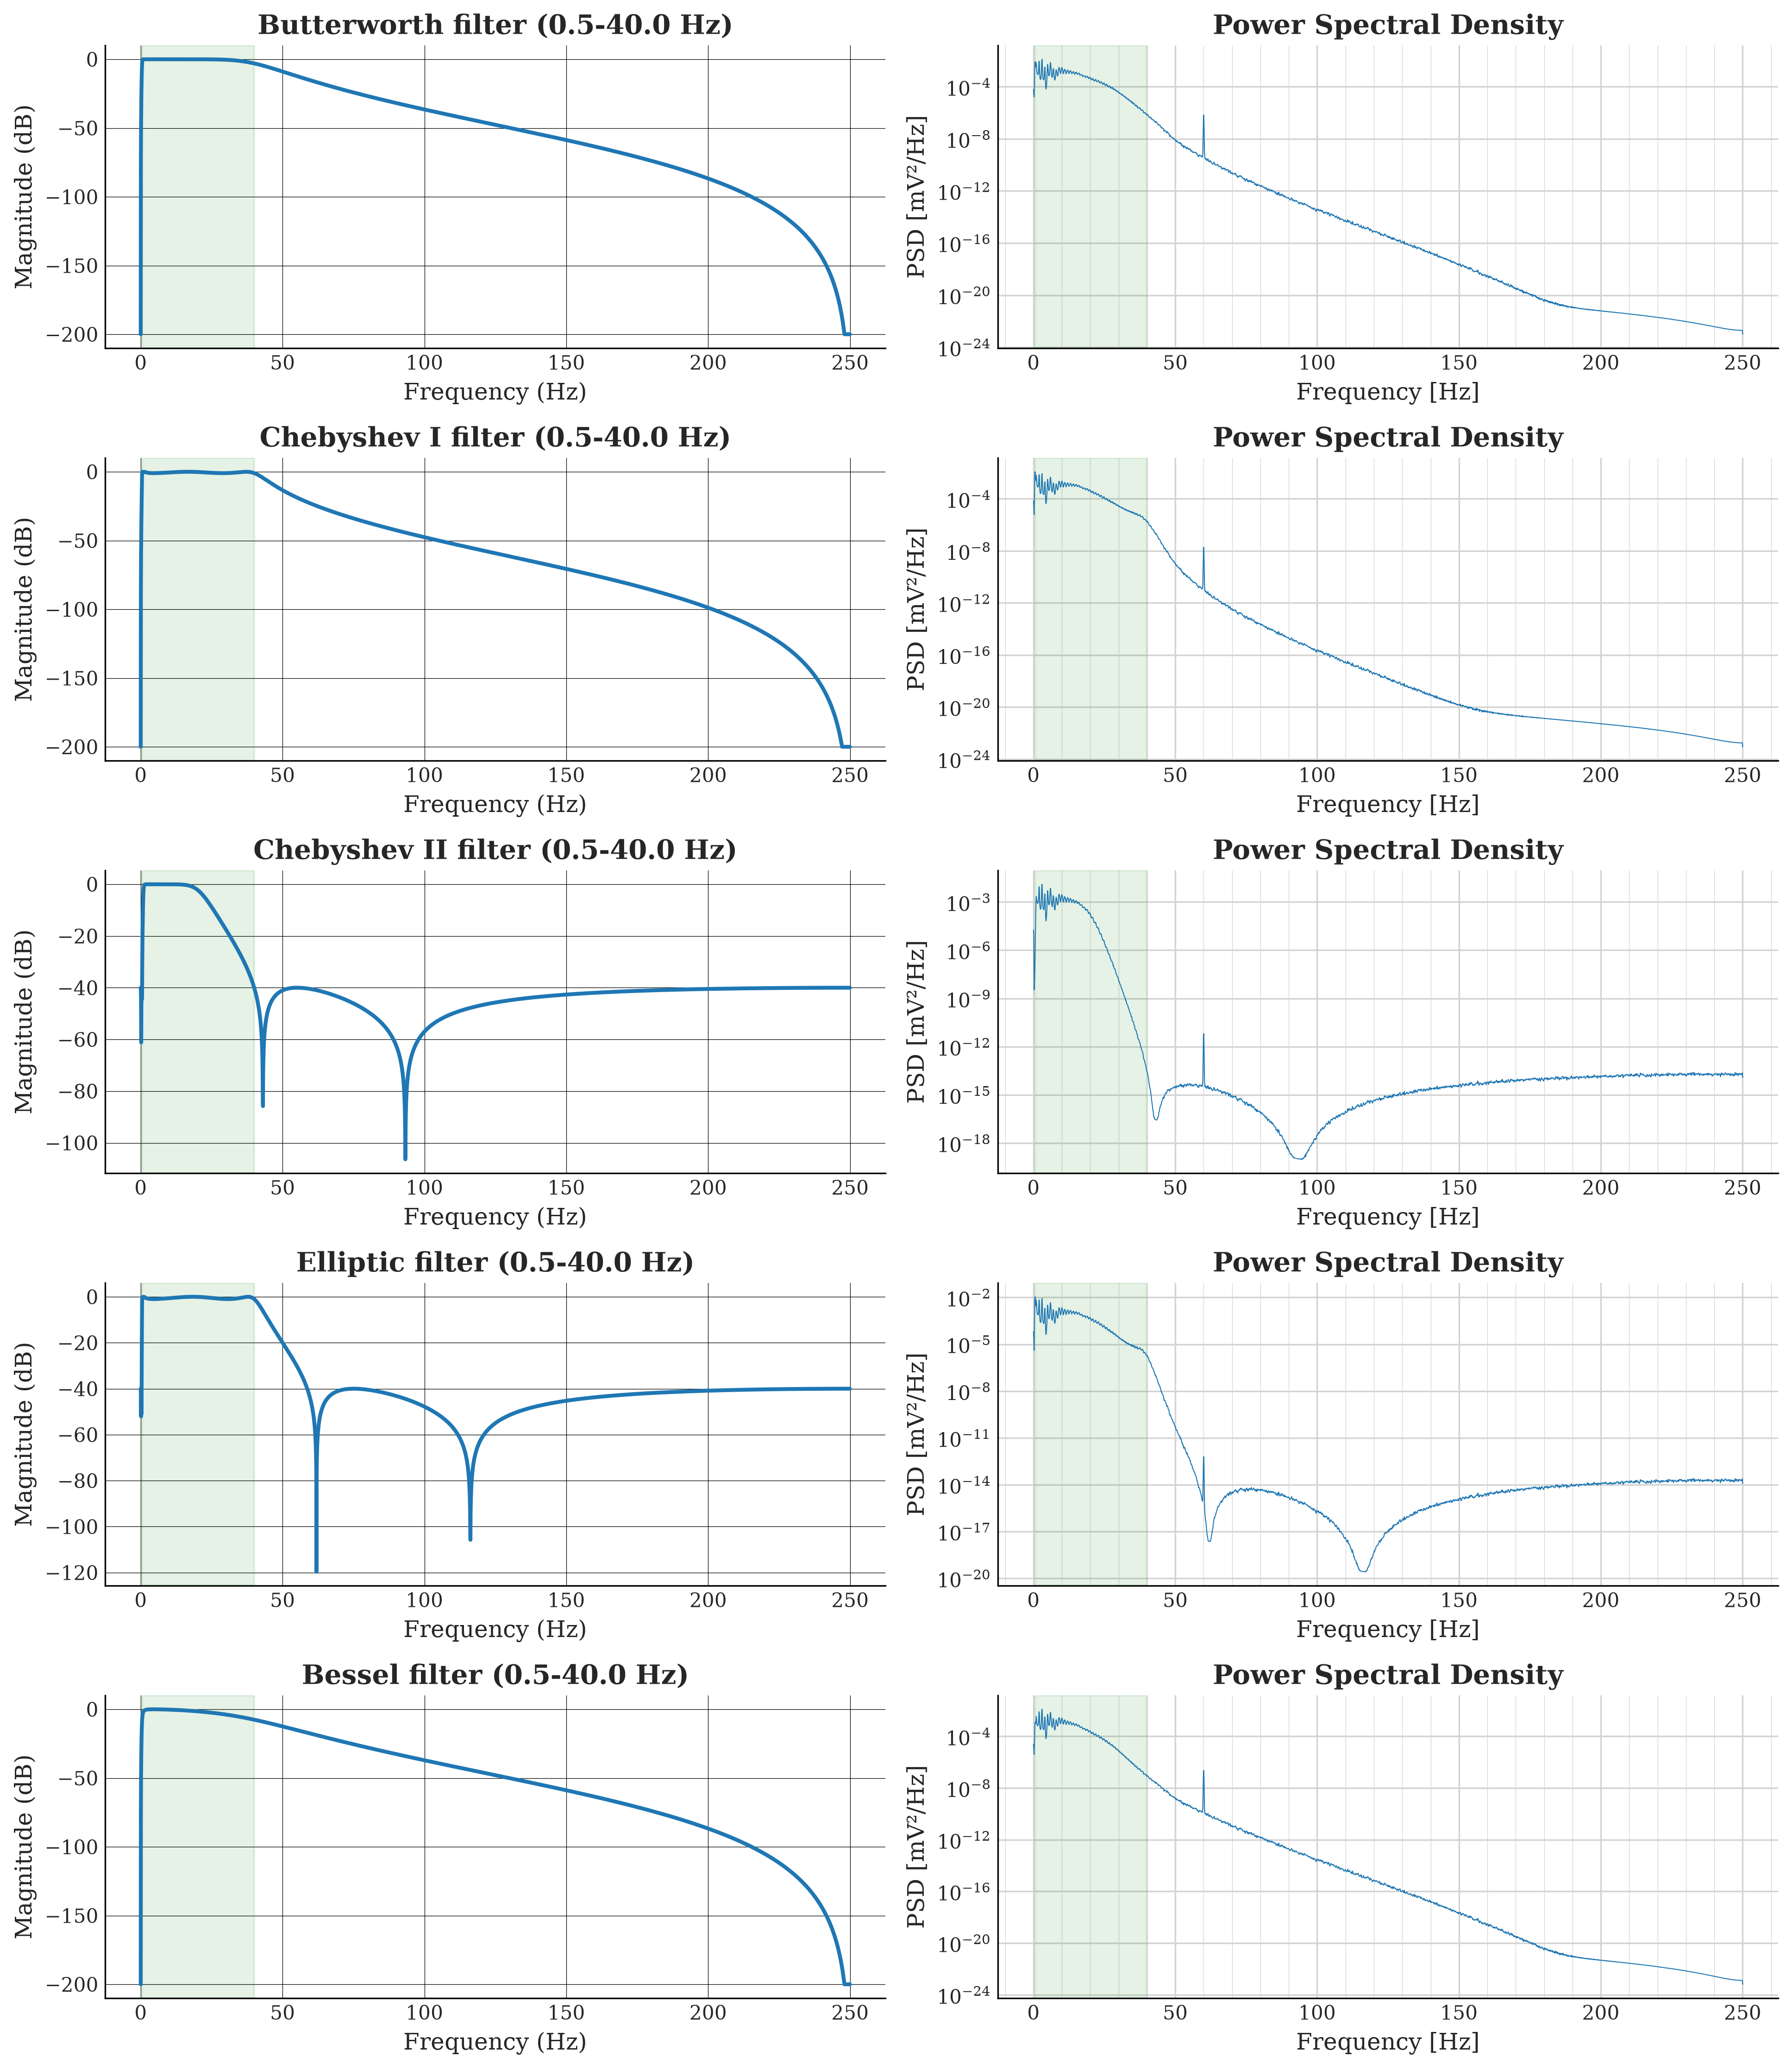

In [16]:
FILTER_DESIGNS = {
    "Butterworth": lambda: butter(
        ORDER,
        [LOW_CUTOFF_HZ, HIGH_CUTOFF_HZ],
        btype="bandpass",
        fs=raw_signal.sample_rate,
        output="sos",
    ),
    "Chebyshev I": lambda: cheby1(
        ORDER,
        RIPPLE_DB,
        [LOW_CUTOFF_HZ, HIGH_CUTOFF_HZ],
        btype="bandpass",
        fs=raw_signal.sample_rate,
        output="sos",
    ),
    "Chebyshev II": lambda: cheby2(
        ORDER,
        ATTENUATION_DB,
        [LOW_CUTOFF_HZ, HIGH_CUTOFF_HZ],
        btype="bandpass",
        fs=raw_signal.sample_rate,
        output="sos",
    ),
    "Elliptic": lambda: ellip(
        ORDER,
        RIPPLE_DB,
        ATTENUATION_DB,
        [LOW_CUTOFF_HZ, HIGH_CUTOFF_HZ],
        btype="bandpass",
        fs=raw_signal.sample_rate,
        output="sos",
    ),
    "Bessel": lambda: bessel(
        ORDER,
        [LOW_CUTOFF_HZ, HIGH_CUTOFF_HZ],
        btype="bandpass",
        fs=raw_signal.sample_rate,
        output="sos",
    ),
}

results = {}
for name, design in FILTER_DESIGNS.items():
    sos = design()
    w, h = sosfreqz(sos, worN=4096, fs=raw_signal.sample_rate)
    filtered = raw_signal.with_sample(sosfiltfilt(sos, raw_signal.sample, padtype=None))

    results[name] = {"w": w, "h": h, "signal": filtered}

fig, axes = plt.subplots(len(results), 2, figsize=(13, 3 * len(results)))

for row, (name, result) in enumerate(results.items()):
    ax, ax_psd = axes[row]

    ax.plot(result["w"], 20 * np.log10(np.maximum(np.abs(result["h"]), 1e-10)), lw=2)
    ax.axvspan(LOW_CUTOFF_HZ, HIGH_CUTOFF_HZ, color="green", alpha=0.1)
    ax.set_title(f"{name} filter ({LOW_CUTOFF_HZ}-{HIGH_CUTOFF_HZ} Hz)")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Magnitude (dB)")

    plot_psd(result["signal"], ax=ax_psd)
    ax_psd.axvspan(LOW_CUTOFF_HZ, HIGH_CUTOFF_HZ, color="green", alpha=0.1)

fig.tight_layout()
plt.show()
save_plot(fig, "Bandpass-filter family response and resulting PSD")

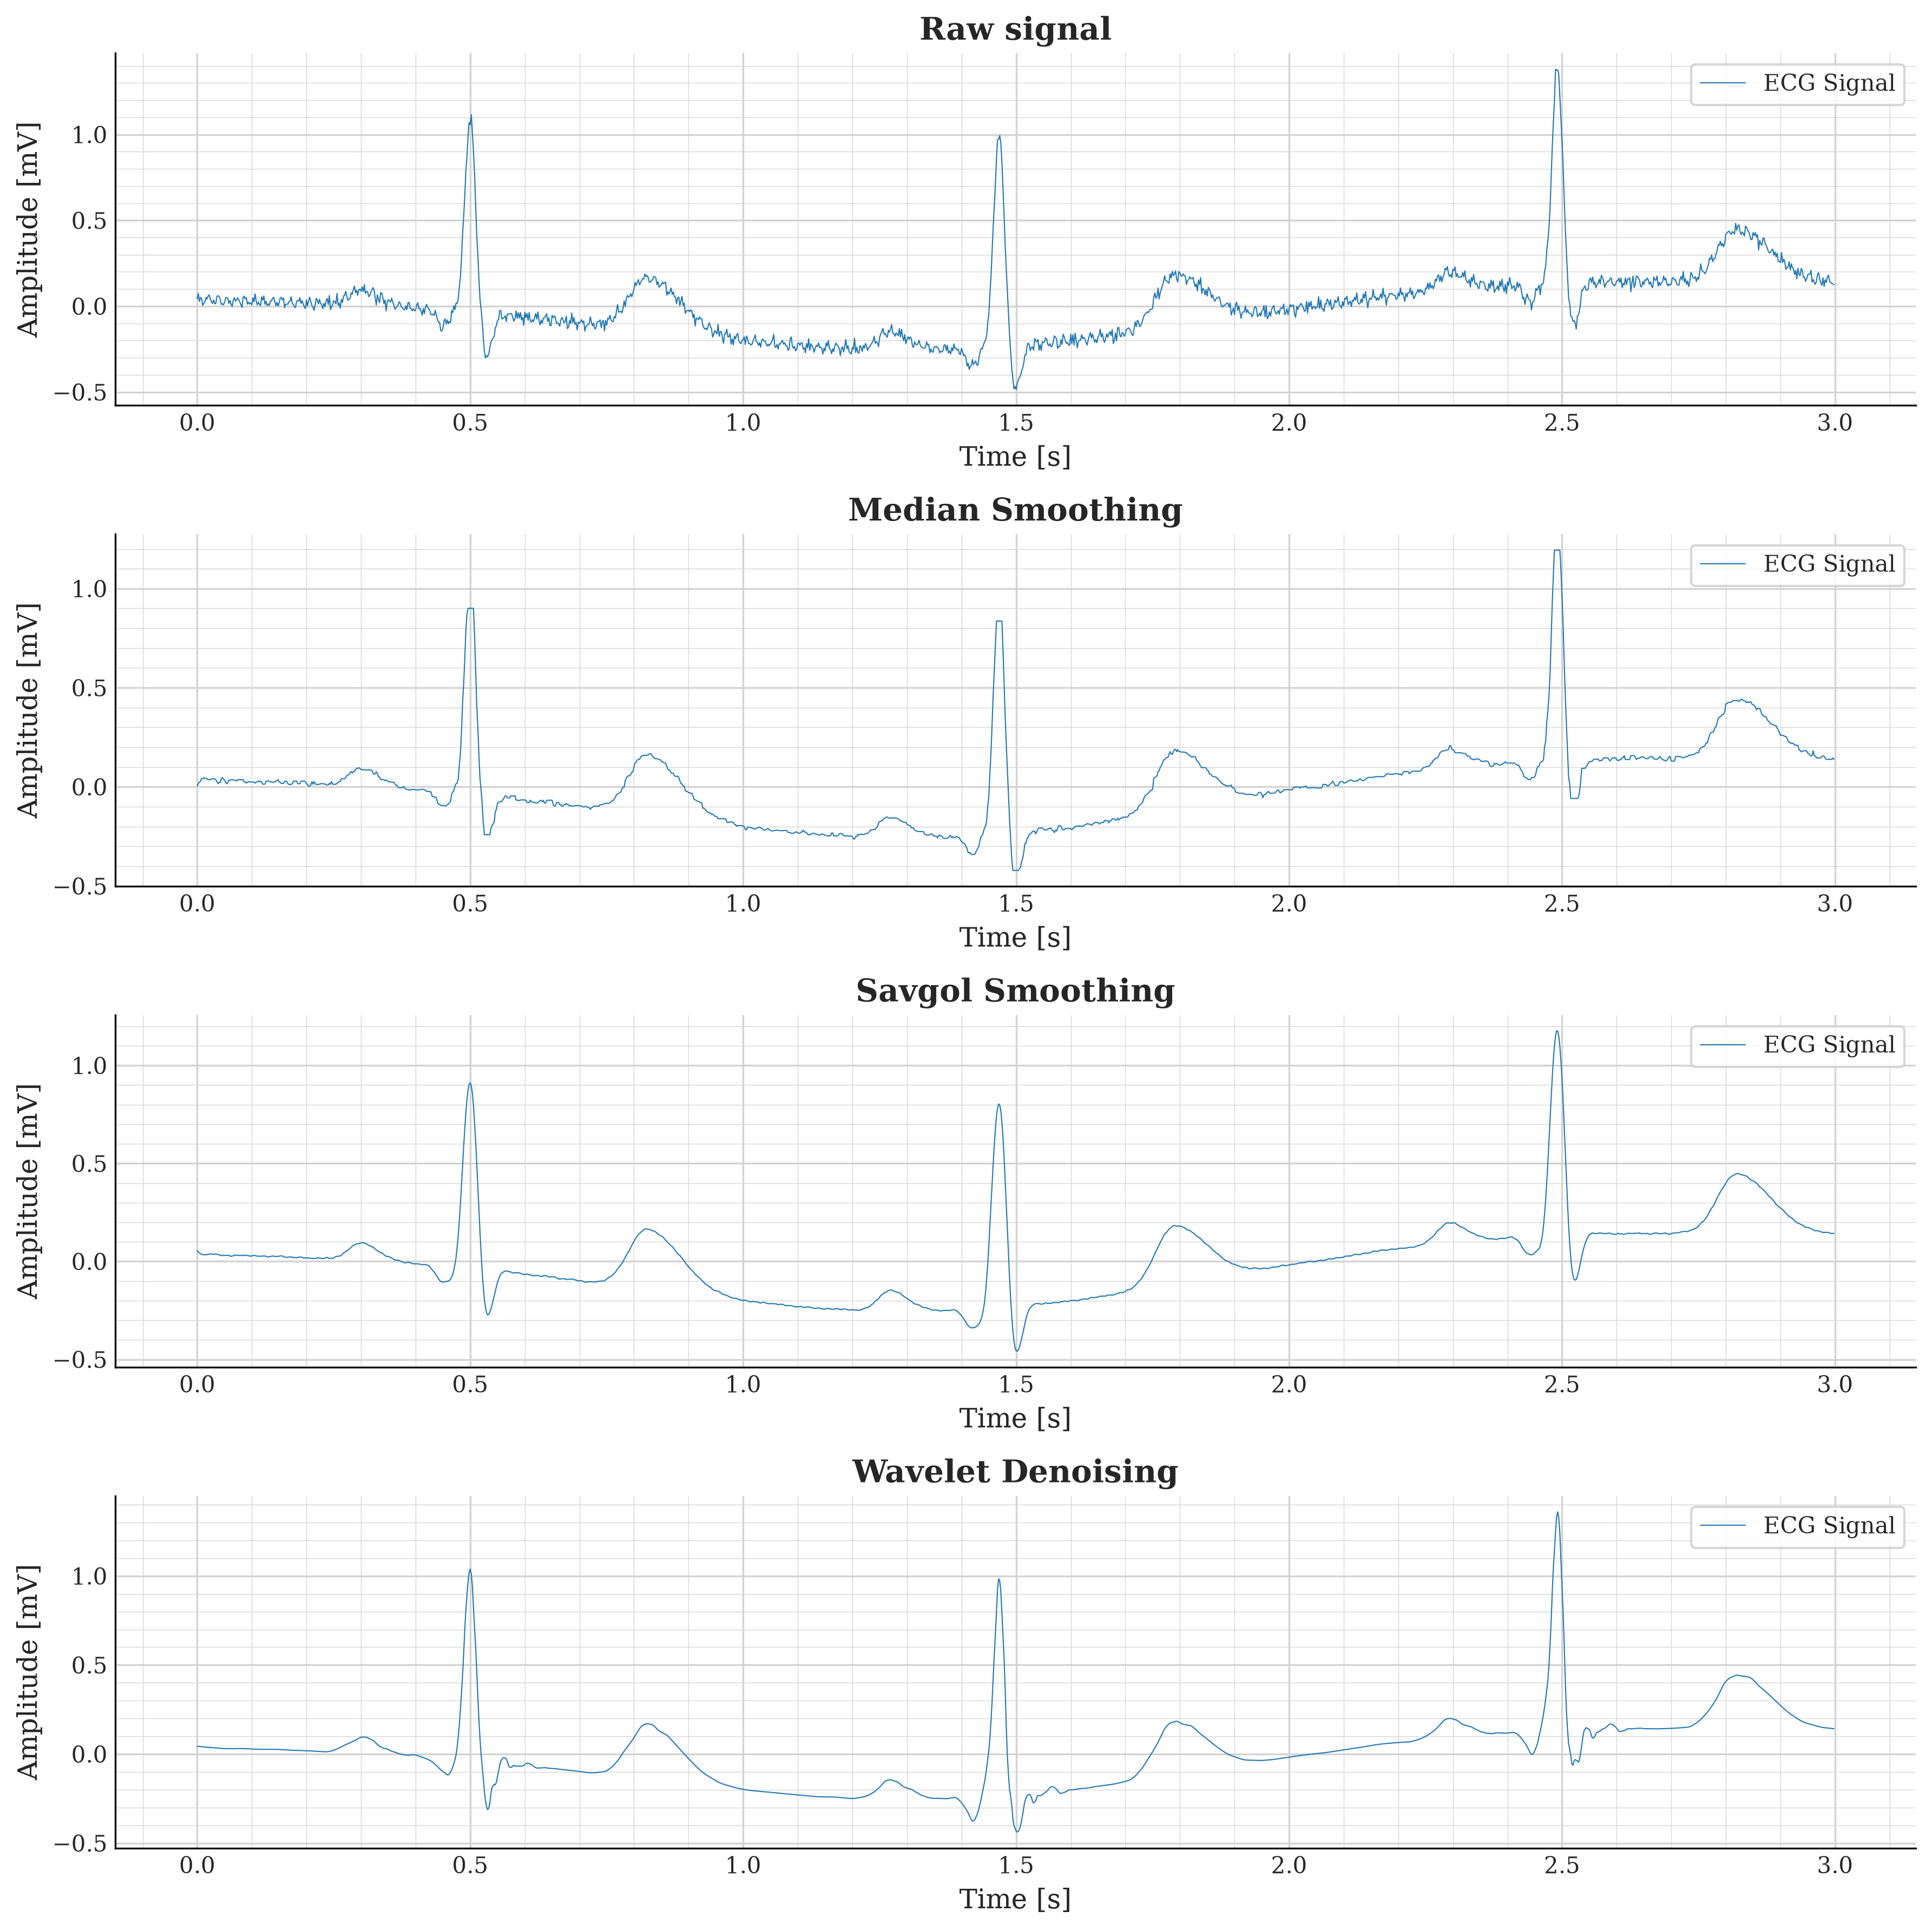

In [17]:
SIGNALS = {
    "Raw signal": raw_signal,
    "Median Smoothing": median_smooth(raw_signal, kernel_ms=KERNEL_MS),
    "Savgol Smoothing": savgol_smooth(
        raw_signal, window_ms=WINDOW_MS, polyorder=POLYORDER
    ),
    "Wavelet Denoising": wavelet_denoise(raw_signal, wavelet=WAVELET, level=LEVEL),
}

fig, axes = plt.subplots(len(SIGNALS), 1, figsize=(12, 3 * len(SIGNALS)))

axes = np.atleast_1d(axes).ravel()

for ax, (name, signal) in zip(axes, SIGNALS.items()):
    plot_signal(
        signal,
        start_sec=0,
        interval_sec=3,
        show_annotation=False,
        title=name,
        ax=ax,
    )

fig.tight_layout()

save_plot(fig, "Denoising filters comparison")

In [18]:
preprocessing_config = {
    "steps": [
        {
            "name": "median_baseline_filter",
            "params": {"window1_ms": WINDOW1_MS, "window2_ms": WINDOW2_MS},
        },
        {
            "name": "notch_filter",
            "params": {"freq": FREQ_50_HZ, "quality_factor": QUALITY_FACTOR},
        },
        {
            "name": "notch_filter",
            "params": {"freq": FREQ_60_HZ, "quality_factor": QUALITY_FACTOR},
        },
        {
            "name": "butterworth_filter",
            "params": {
                "low_cutoff": LOW_CUTOFF_HZ,
                "high_cutoff": HIGH_CUTOFF_HZ,
                "order": ORDER,
            },
        },
    ]
}

preprocessor = Preprocessor.from_config(preprocessing_config)

In [19]:
PREPROCESSING_CONFIG_FILE = "preprocessing/preprocessing_pipeline.yaml"
save_yaml(PREPROCESSING_CONFIG_FILE, preprocessing_config)

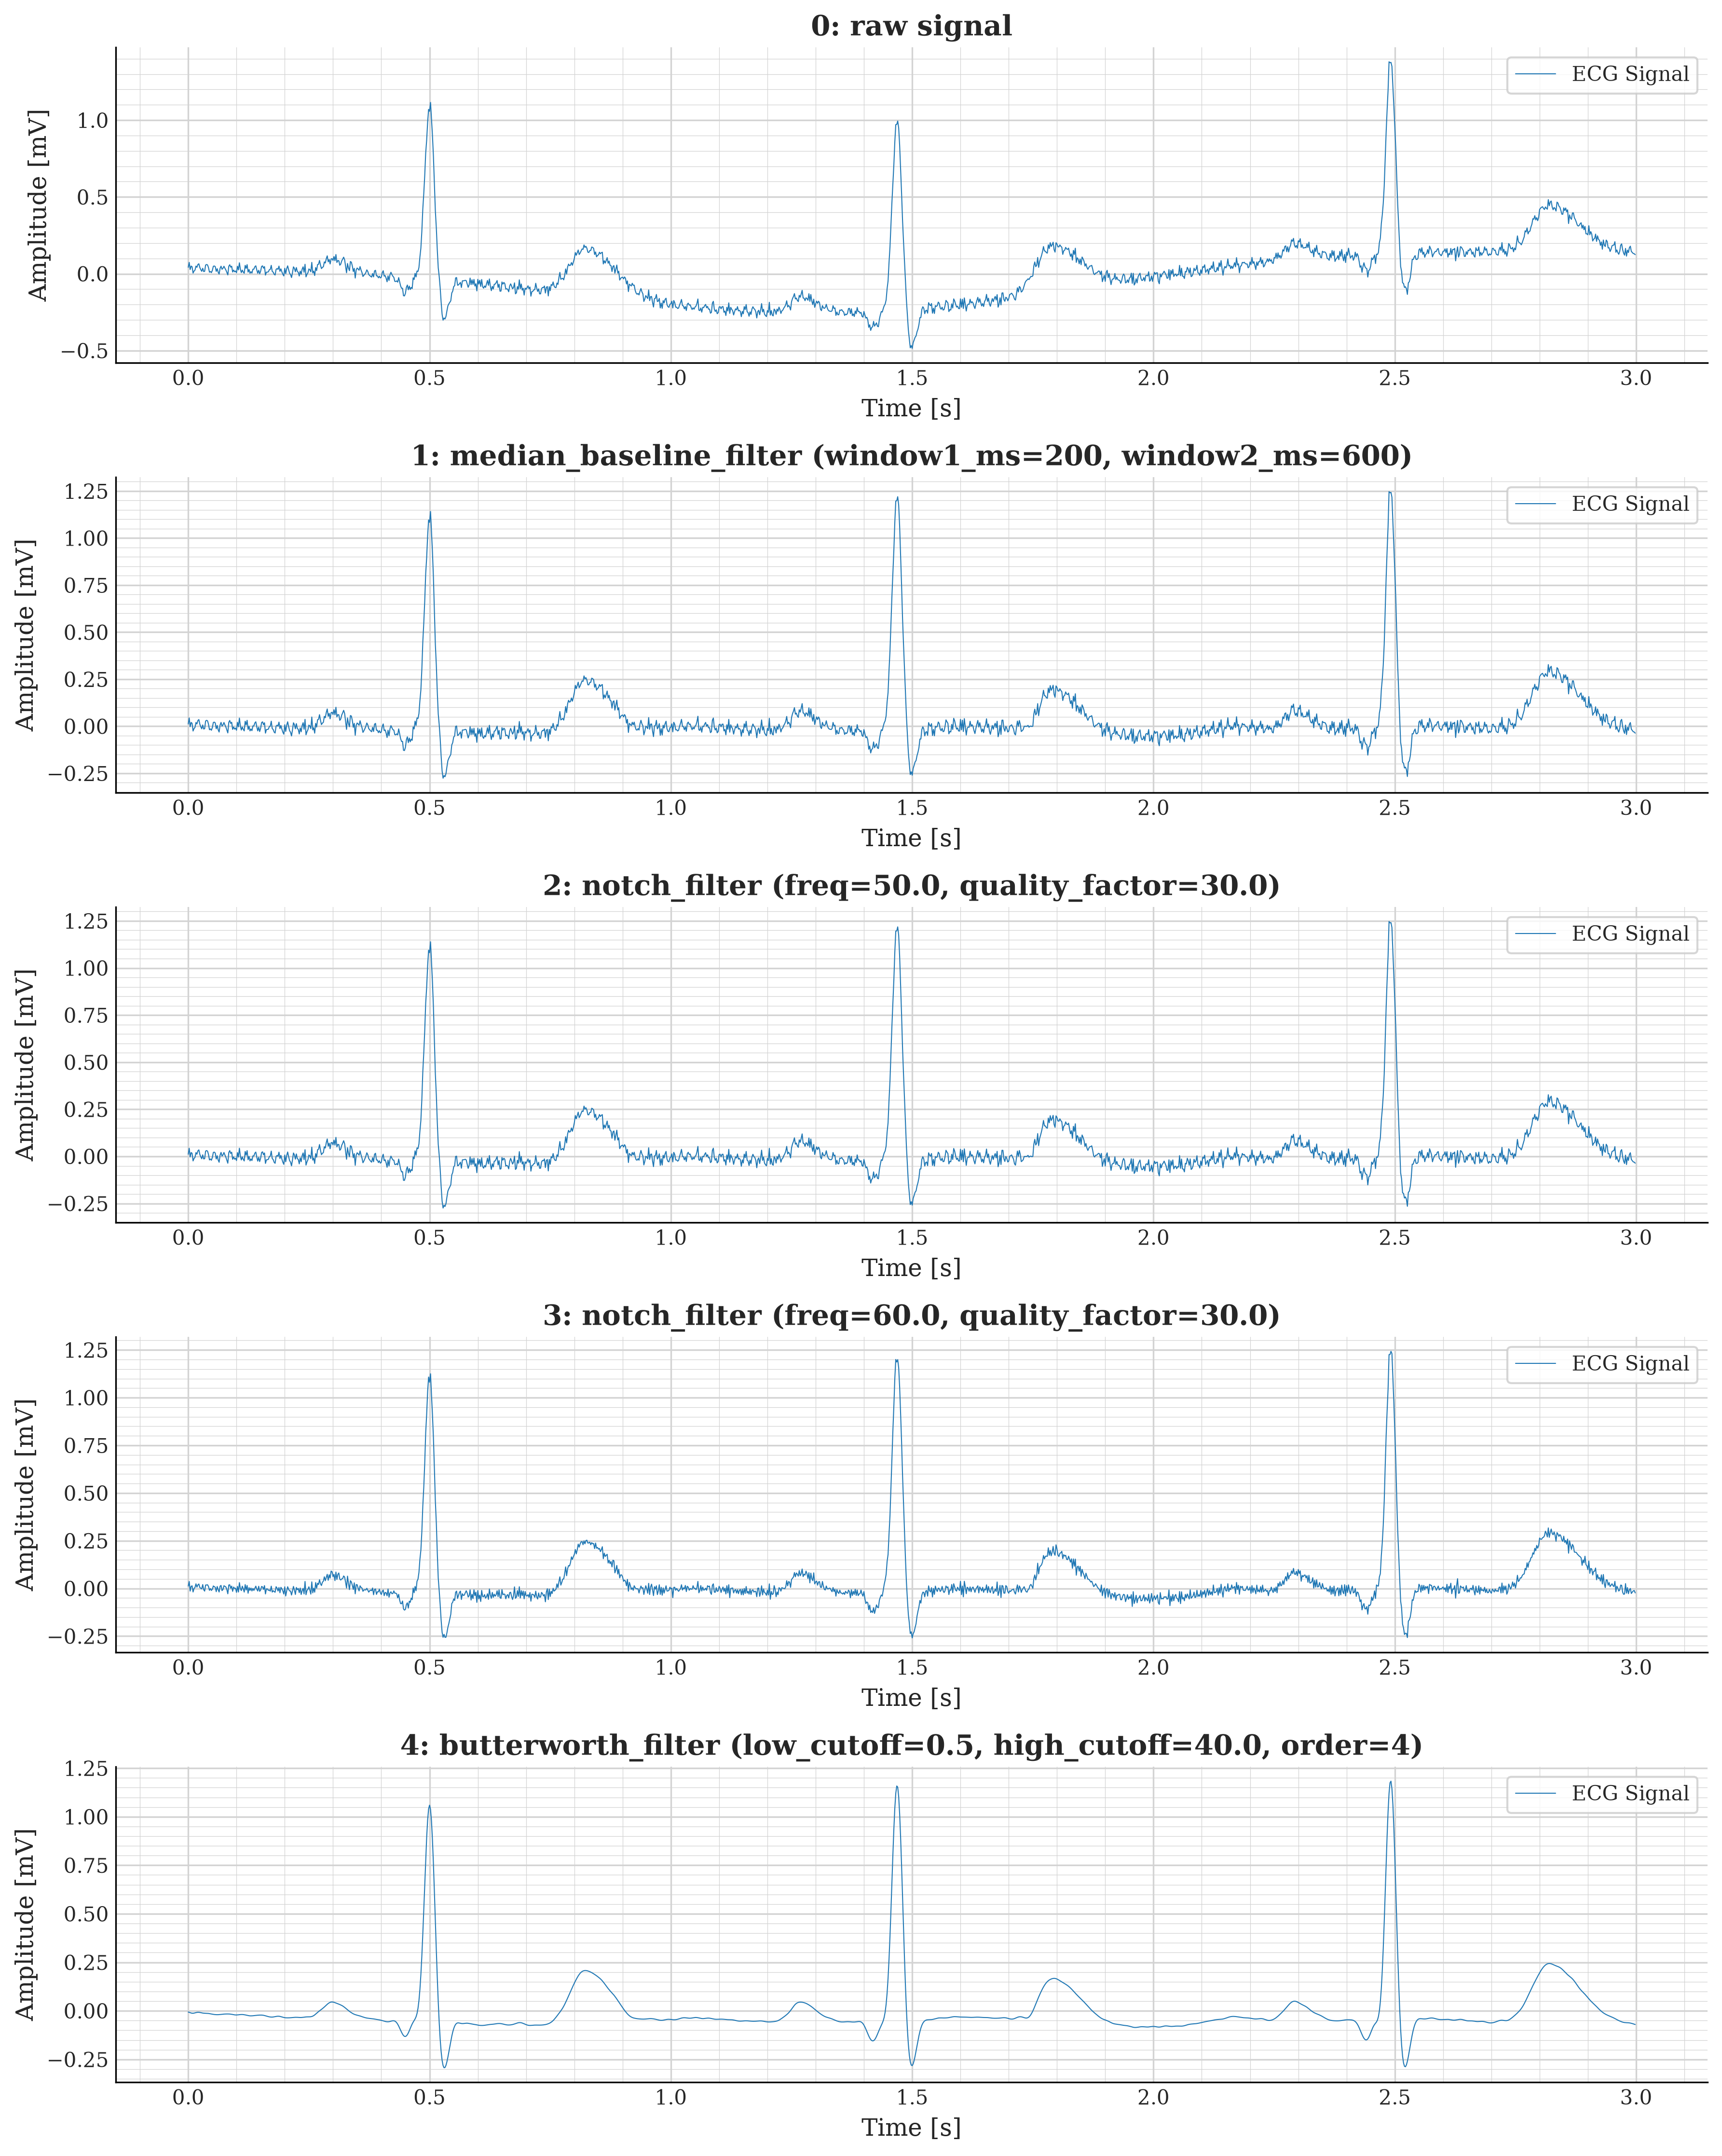

In [20]:
def stage_label(step_config: dict) -> str:
    name = step_config["name"]
    params = step_config.get("params")
    if params:
        param_str = ", ".join(f"{k}={v}" for k, v in params.items())
        return f"{name} ({param_str})"
    return name


pipeline = {"0: raw signal": raw_signal}
current = raw_signal
for i, (step_config, step) in enumerate(
    zip(preprocessor.step_configs, preprocessor.steps), start=1
):
    current = step(current)
    pipeline[f"{i}: {stage_label(step_config)}"] = current

fig, axes = plt.subplots(len(pipeline), 1, figsize=(12, 3 * len(pipeline)))

axes = np.atleast_1d(axes).ravel()

for ax, (name, signal) in zip(axes, pipeline.items()):
    plot_signal(
        signal,
        start_sec=0,
        interval_sec=3,
        show_annotation=False,
        title=name,
        ax=ax,
    )

fig.tight_layout()

save_plot(fig, "Preprocessing pipeline stepwise breakdown")

In [21]:
cleaned_signal = preprocessor(raw_signal)

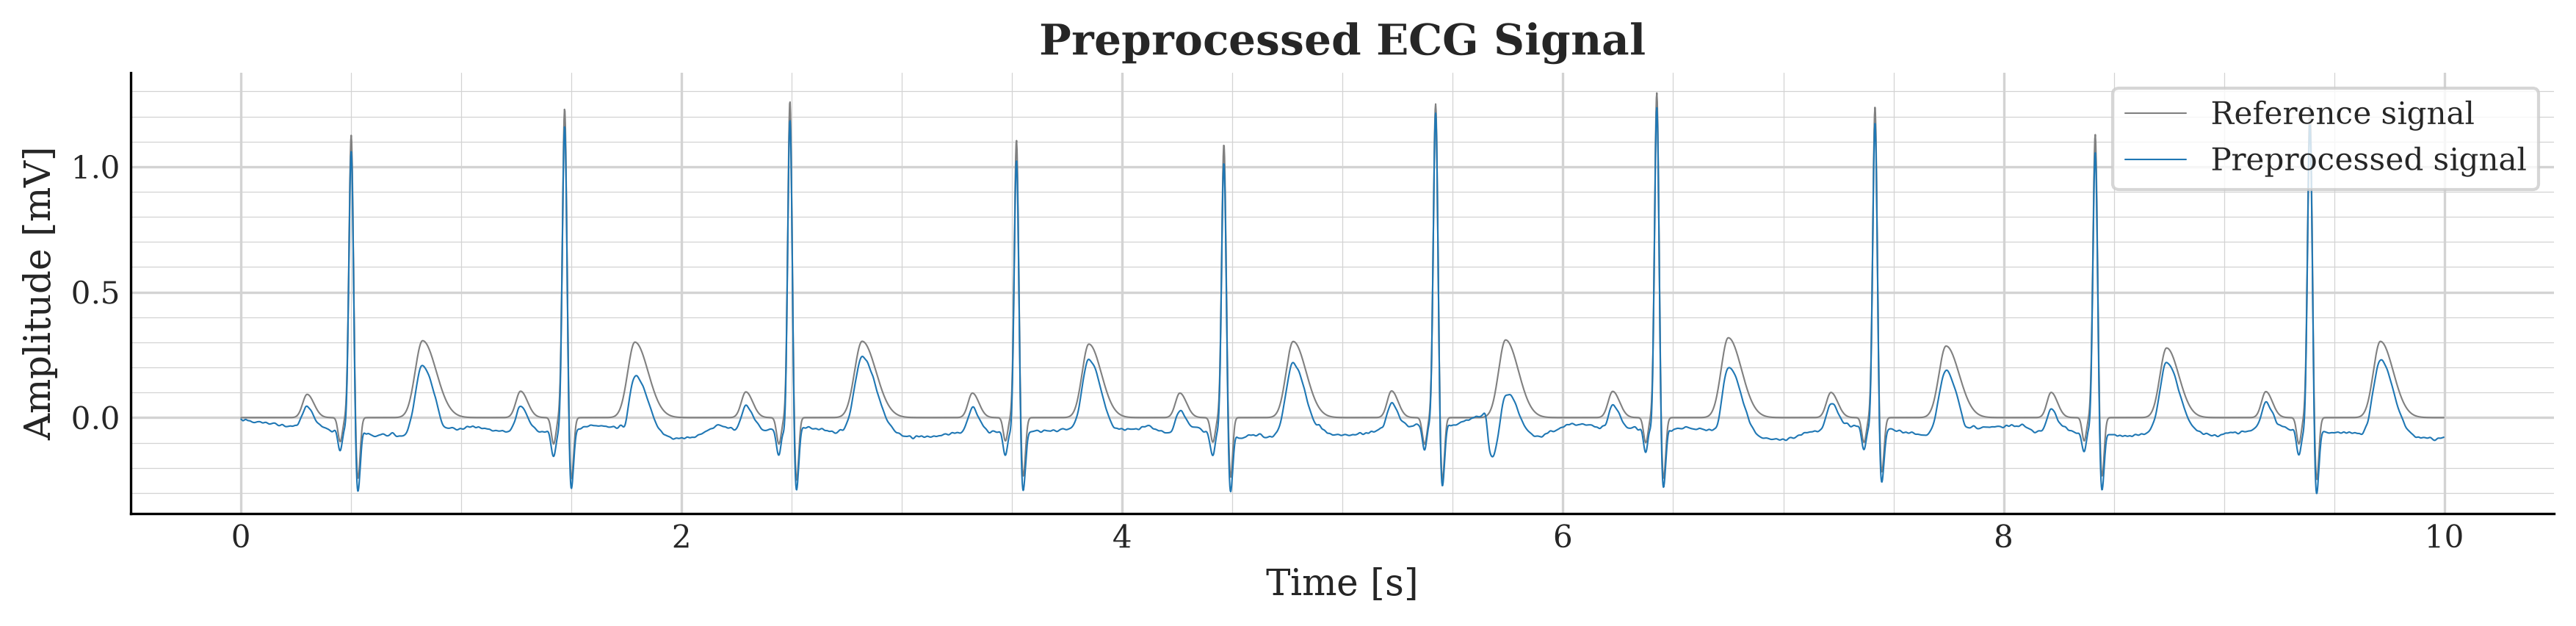

In [22]:
fig, ax = plt.subplots()

plot_signal(
    reference_signal,
    start_sec=0,
    interval_sec=10,
    show_annotation=False,
    ax=ax,
    color="gray",
    label="Reference signal",
)

plot_signal(
    cleaned_signal,
    start_sec=0,
    interval_sec=10,
    show_annotation=False,
    ax=ax,
    label="Preprocessed signal",
)

ax.set_title("Preprocessed ECG Signal")

fig.tight_layout(rect=(0, 0, 1, 0.98))

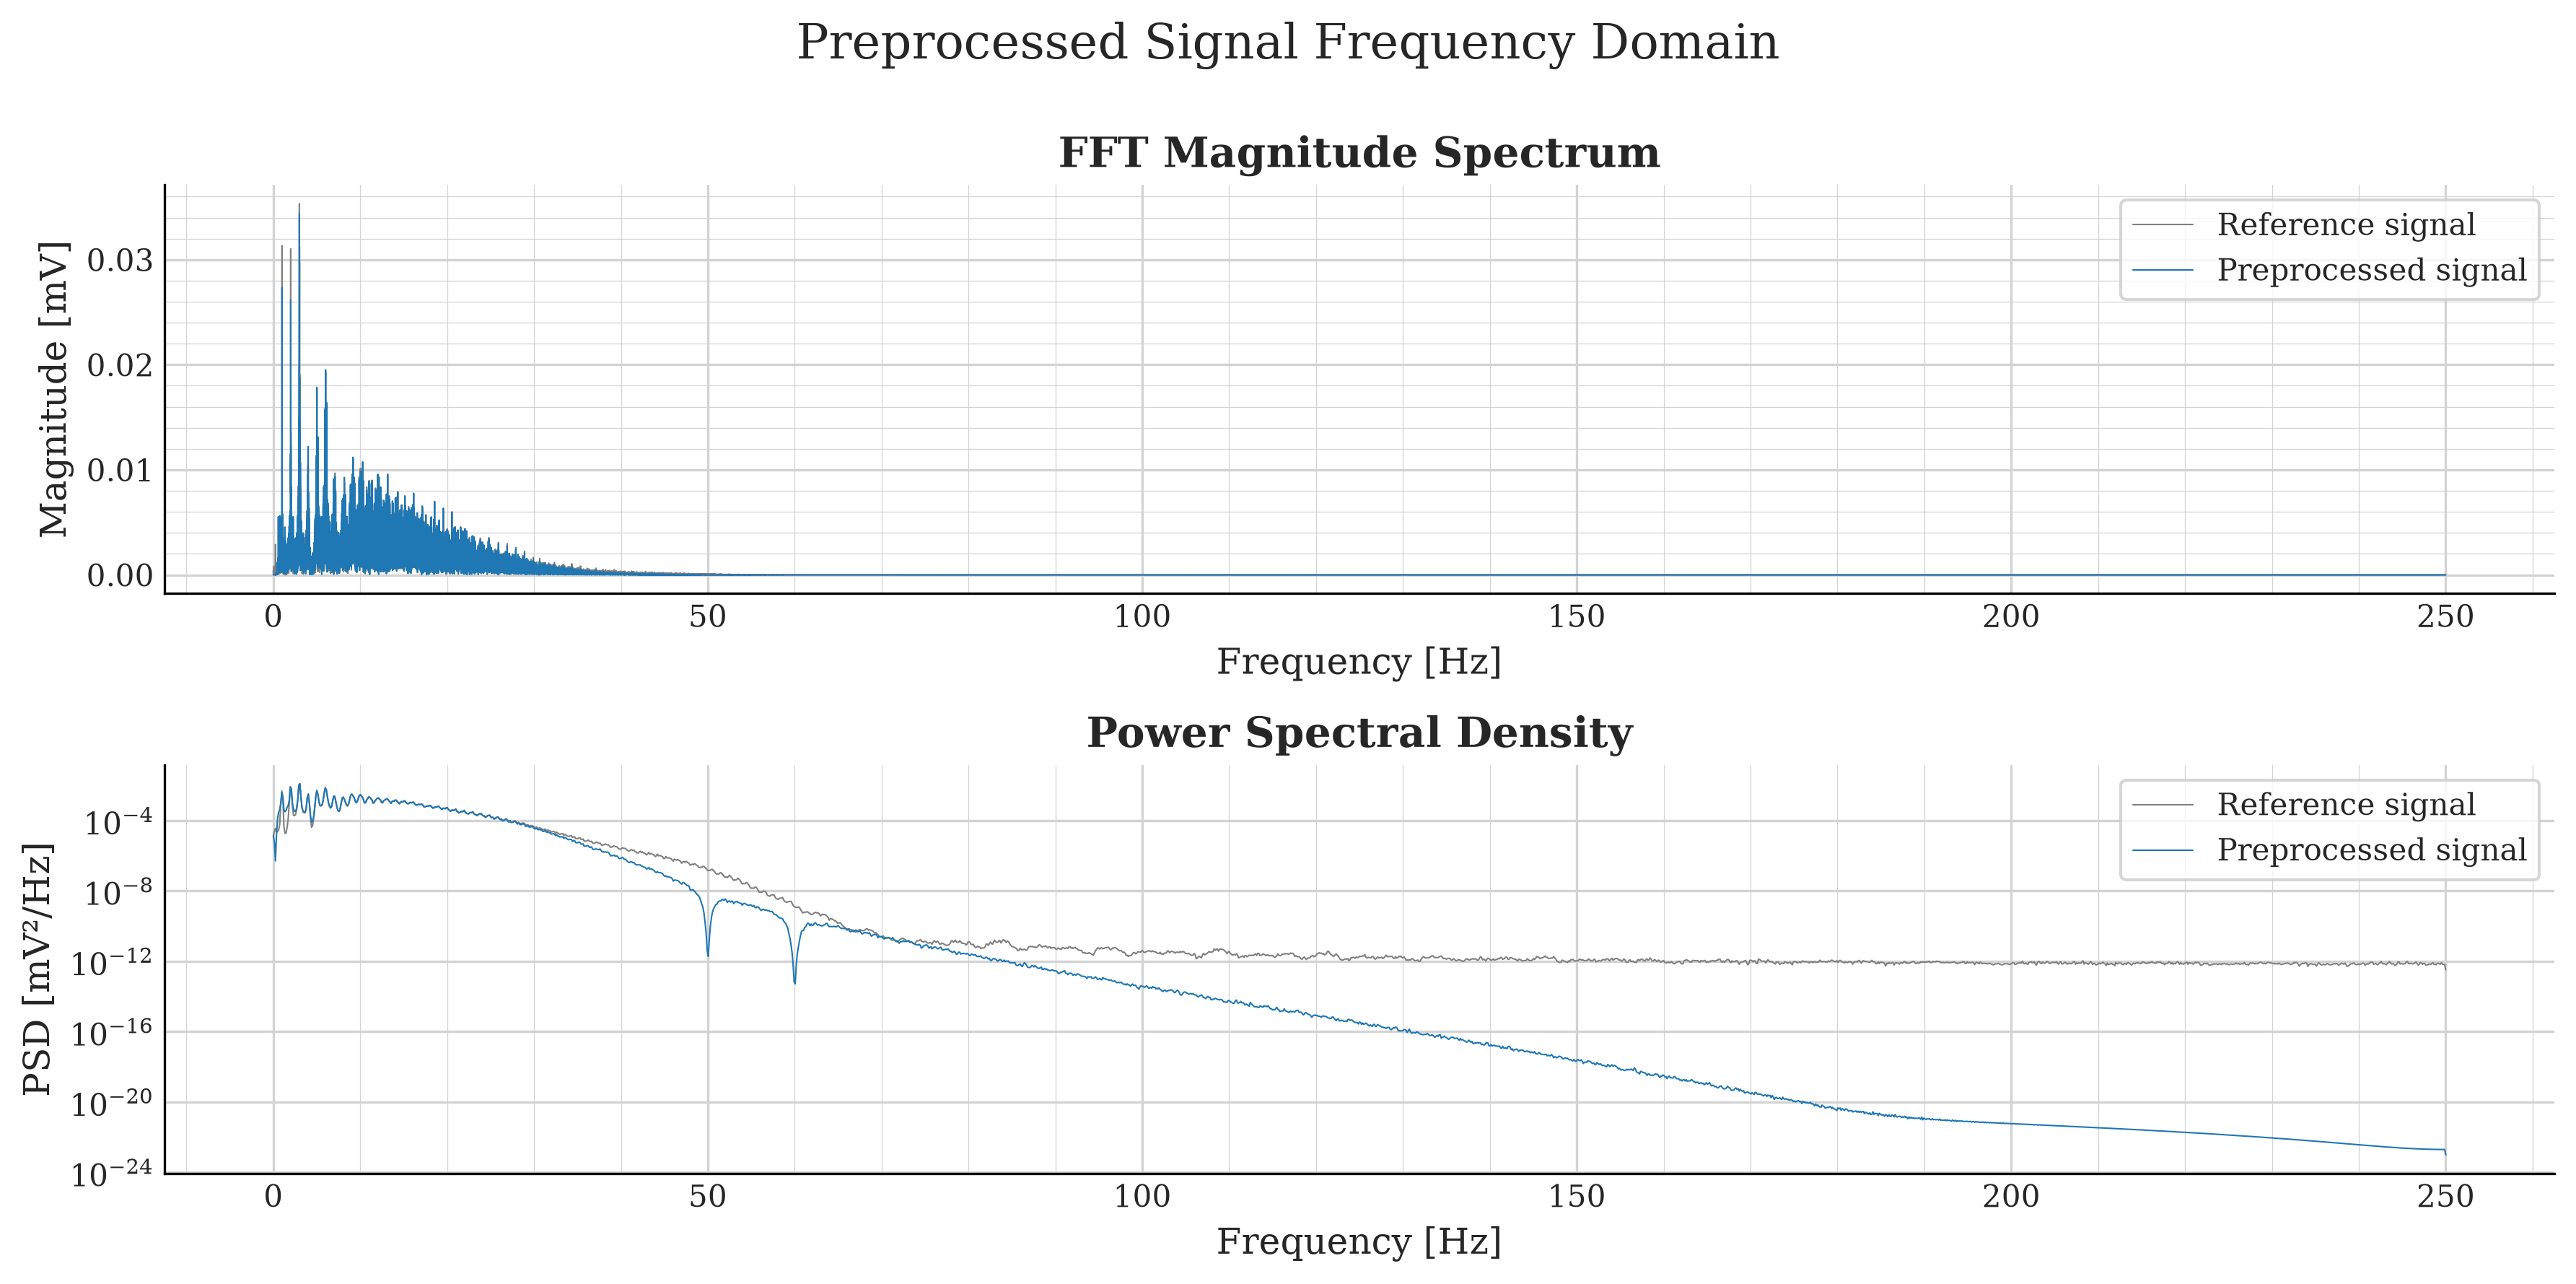

In [23]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

plot_fft(reference_signal, ax=ax1, color="gray", label="Reference signal")
plot_psd(reference_signal, ax=ax2, color="gray", label="Reference signal")

plot_fft(cleaned_signal, ax=ax1, label="Preprocessed signal")
plot_psd(cleaned_signal, ax=ax2, label="Preprocessed signal")

ax1.legend()
ax2.legend()

fig.suptitle("Preprocessed Signal Frequency Domain", fontsize=16)
fig.tight_layout(rect=(0, 0, 1, 0.98))

In [24]:
snr = compute_snr(reference_signal, cleaned_signal)

print(f"SNR = {snr:.2f} dB")

result = assessor.assess(cleaned_signal)

print(result)

SNR = 8.14 dB
QualityReport[ACCEPTABLE, score=0.93]
  kurtosis_sqi           =  20.5225  [GOOD]
  qrs_power_sqi          =   0.5360  [GOOD]
  powerline_50hz         =   0.0000  [GOOD]
  powerline_60hz         =   0.0000  [GOOD]
  baseline_wander_ratio  =   0.0732  [ACCEPTABLE]
  flatline_ratio         =   0.0000  [GOOD]


---